# Text Mining Project — Market Sentiment Classification
**Spring Semester 2025/2026 | NOVA IMS**

Classifying financial tweets into three sentiment categories:
- **0 — Bearish** (negative / pessimistic)
- **1 — Bullish** (positive / optimistic)
- **2 — Neutral**

---
<a class='anchor' id='toc'></a>
## Table of Contents

1. [Setup & Imports](#1)
2. [Data Exploration](#2)
   - [2.1 Dataset Overview & Duplicates](#2-1)
   - [2.2 Class Distribution](#2-2)
   - [2.3 Tweet Length Analysis](#2-3)
   - [2.4 Global Vocabulary](#2-4)
   - [2.5 Top Words per Class](#2-5)
   - [2.6 Financial Sentiment Words](#2-6)
   - [2.7 N-gram Analysis (Bigrams & Trigrams)](#2-7)
   - [2.8 Special Features (Hashtags, Mentions, URLs)](#2-8)
   - [2.8b Uppercase Analysis](#2-8b)
   - [2.8c Mention (@) Analysis](#2-8c)
   - [2.8d Hashtag (#) Deep-Dive](#2-8d)
   - [2.8e Emoji Analysis](#2-8e)
   - [2.8f Special Characters (+ - ! ? < >)](#2-8f)
   - [2.9 Top Hashtags & Cashtags per Class](#2-9)
   - [2.10 Tweets with Little Content After Cleaning](#2-10)
   - [2.11 Exclusive Vocabulary per Class](#2-11)
   - [2.12 Lexical Dispersion](#2-12)
   - [2.13 Co-occurrence Heatmap](#2-13)
   - [2.14 Tweet Length Boxplot & Statistical Test](#2-14)
   - [2.15 Exploration Summary & Conclusions](#2-15)
3. [Data Preprocessing](#3)
   - [3.1 Step-by-step Demonstration](#3-1)
   - [3.2 Lemmatization vs Stemming](#3-2)
   - [3.3 Preprocessing Functions](#3-3)
   - [3.4 Apply to Full Training Set](#3-4)
   - [3.5 Before / After Comparison](#3-5)
   - [3.6 Vocabulary Impact](#3-6)
   - [3.7 Empty Tweets After Cleaning](#3-7)
4. [Corpus Split — Stratified K-Fold](#4)
5. [Feature Engineering](#5)
   - [5.1 BoW & TF-IDF](#5-1)
   - [5.2 Word2Vec](#5-2)
   - [5.3 Transformer Encoder Embeddings](#5-3)
6. [Classification Models](#6)
   - [6.1 Evaluation Helper](#6-1)
   - [6.2 Traditional ML — TF-IDF Pipeline](#6-2)
   - [6.3 Traditional ML — Word2Vec Pipeline](#6-3)
   - [6.4 Transformer Encoder + Classifier Head](#6-4)
   - [6.5 Fine-tuned FinBERT (End-to-end)](#6-5)
7. [Evaluation & Analysis](#7)
8. [Final Predictions on test.csv](#8)

<a class='anchor' id='1'></a>
---
## 1. Setup & Imports

In [1]:
!pip install nltk gensim xgboost wordsegment -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import re, string, warnings
from scipy import stats
warnings.filterwarnings('ignore')

import nltk
for pkg in ['stopwords','punkt','punkt_tab','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.util import ngrams

STOP         = set(stopwords.words('english'))
lemma        = WordNetLemmatizer()
stemmer      = SnowballStemmer('english')
CLASS_COLORS = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
CLASS_NAMES  = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}


[↑ Back to TOC](#toc)

<a class='anchor' id='2'></a>
---
## 2. Data Exploration

<a class='anchor' id='2-1'></a>
### 2.1 Dataset Overview & Duplicates

### **Dataset Overview**

This first step provides a general overview of the dataset, including its dimensions, variables, data types, missing values, and initial observations.

In [4]:
df = pd.read_csv('train.csv')
# Print the dimensions of the DataFrame (rows, columns)
print(f'Shape: {df.shape}')

# Print the list of column names
print(f'Columns: {list(df.columns)}')

# Print the data type of each column
print(f'Types:\n{df.dtypes}')

# Print the count of missing (NaN) values per column
print(f'\nMissing values:\n{df.isnull().sum()}')

# Display the first 10 rows of the DataFrame
df.head(10)

Shape: (9543, 2)
Columns: ['text', 'label']
Types:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


This step checks whether the training dataset contains duplicated tweets or tweets that appear multiple times with different sentiment labels.

In [5]:
# Count rows with duplicate text (regardless of label)
exact_duplicates = df.duplicated(subset='text').sum()
# Count rows with duplicate text AND label
label_duplicates = df.duplicated(subset=['text', 'label']).sum()

print(f'Duplicate tweets (same text): {exact_duplicates}')
print(f'Duplicate tweets (same text + label): {label_duplicates}')

# Show duplicate examples if any exist
if exact_duplicates > 0:
    mask = df.duplicated(subset='text', keep=False)
    print(f'\nDuplicate tweet examples:')
    print(df[mask][['text','label']].sort_values('text').head(10).to_string())
    
    # Edge case: same tweet with conflicting labels — dangerous for training!
    conflicts = df[mask].groupby('text')['label'].nunique()
    conflicts = conflicts[conflicts > 1]  # Keep only texts with more than one distinct label
    print(f'\nTweets with conflicting labels (same text, different label): {len(conflicts)}')
    if len(conflicts) > 0:
        # Show the conflicting rows
        print(df[df['text'].isin(conflicts.index)][['text','label']].sort_values('text').head(10).to_string())

Duplicate tweets (same text): 0
Duplicate tweets (same text + label): 0


**Dataset Overview and Duplicate Analysis - Conclusion:**

- **Dataset structure:**  
  The training dataset contains 9543 tweets and 2 columns: `text` and `label`. The `text` column contains the tweet content, while the `label` column contains the sentiment class assigned to each tweet.

- **Data types:**  
  The data types are appropriate for this classification task. The `text` column is stored as an object/string variable, and the `label` column is stored as an integer, which is suitable for representing the sentiment classes.

- **Missing values:**  
  No missing values were found in either column. This means that no tweets need to be removed or imputed due to missing text or labels.

- **Duplicate records:**  
  No duplicated tweets were found in the dataset. There were also no duplicated rows with the same text and label. Therefore, there is no evidence of repeated tweets or conflicting duplicated labels in the training data.

  Overall, the dataset is clean and structurally suitable for the next stages of the project. The main variables are available, the data types are correct, and no missing or duplicated records were detected.

[↑ Back to TOC](#toc)

<a class='anchor' id='2-2'></a>
### 2.2 Class Distribution

This analysis examines the distribution of the three sentiment classes and helps identify possible class imbalance in the dataset. 

Class count
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


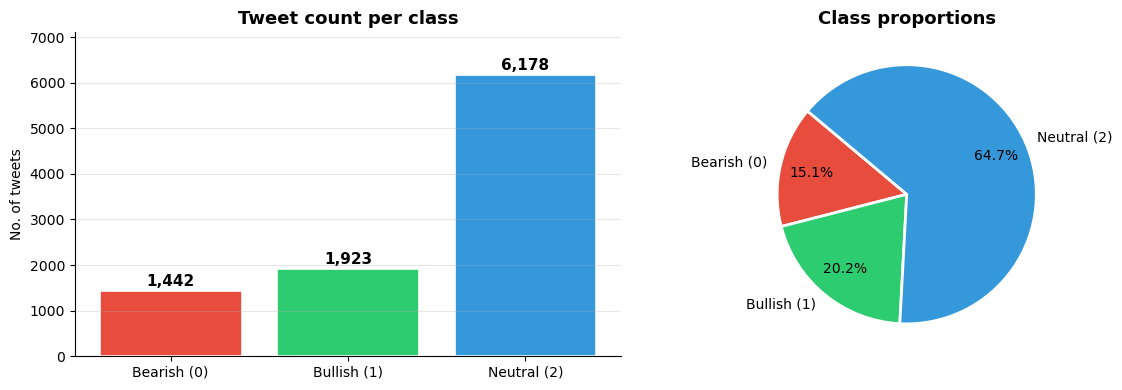


Baseline (majority class): 64.7% — any model should beat this value.


In [6]:
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

print('Class count')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — count per class with value labels on top
colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Tweet count per class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('No. of tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart — class proportions
axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Majority class baseline: accuracy of a model that always predicts the most frequent class.
# Any trained model must beat this, otherwise it has learned nothing useful.
majority_acc = label_counts.max() / len(df) * 100
print(f'\nBaseline (majority class): {majority_acc:.1f}% — any model should beat this value.')

**Class Distribution - Conclusion:**

- **Imbalanced dataset:**  
  The class distribution shows a clear imbalance in the training data. Neutral tweets represent the majority class, with 6178 tweets (64.7%), while Bullish tweets account for 1923 tweets (20.2%) and Bearish tweets for only 1442 tweets (15.1%).

- **Majority class baseline:**  
  Since the Neutral class represents 64.7% of the dataset, a simple model that always predicts Neutral would already achieve 64.7% accuracy. Therefore, accuracy alone may be misleading, as it could hide poor performance on the minority classes.

- **Impact on model evaluation and metric choice:**  
  Because Bearish and Bullish tweets are less represented, models may become biased toward the Neutral class if the imbalance is not considered. For this reason, Macro F1-score will be used as an important evaluation metric in the modelling stage. Unlike accuracy, Macro F1-score gives equal importance to each class, making it more appropriate for evaluating performance in an imbalanced multi-class classification problem.

[↑ Back to TOC](#toc)

<a class='anchor' id='2-3'></a>
### 2.3 Tweet Length Analysis

=== Length statistics ===
       n_chars  n_words
count   9543.0   9543.0
mean      85.9     12.2
std       35.1      4.7
min        2.0      1.0
25%       58.0      9.0
50%       79.0     11.0
75%      120.0     15.0
max      190.0     32.0


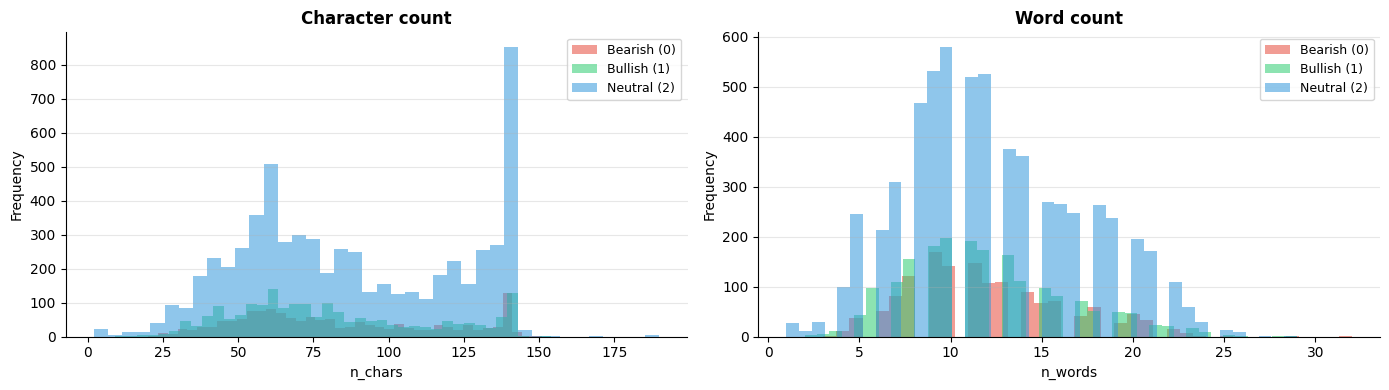


=== Average length per class ===
             n_chars  n_words
label                        
Bearish (0)     83.4     12.0
Bullish (1)     80.4     11.9
Neutral (2)     88.1     12.3


In [184]:
df['n_chars']  = df['text'].str.len()
df['n_words']  = df['text'].str.split().str.len()
df['n_tokens'] = df['text'].apply(lambda x: len(word_tokenize(str(x))))

print('=== Length statistics ===')
print(df[['n_chars','n_words']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for metric, ax, title in [('n_chars', axes[0], 'Character count'), ('n_words', axes[1], 'Word count')]:
    for lbl in [0,1,2]:
        ax.hist(df[df['label']==lbl][metric], bins=40, alpha=0.55,
                color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric); ax.set_ylabel('Frequency')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print('\n=== Average length per class ===')
print(df.groupby('label')[['n_chars','n_words']].mean().round(1).rename(index=CLASS_NAMES))

[↑ Back to TOC](#toc)

<a class='anchor' id='2-4'></a>
### 2.4 Global Vocabulary

In [185]:
def tokenize_explore(text):
    """Lightweight tokeniser for exploration only — no model fitting."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]

all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_explore(txt))

vocab = set(all_tokens)
freq  = Counter(all_tokens)
top50 = freq.most_common(50)

print(f'Total tokens (no stopwords): {len(all_tokens):,}')
print(f'Unique vocabulary:           {len(vocab):,}')
print('\nTop 20 most frequent words:')
for word, cnt in top50[:20]:
    print(f'   {word:<20} {cnt:>5}')

Total tokens (no stopwords): 73,385
Unique vocabulary:           14,016

Top 20 most frequent words:
   stock                  611
   new                    417
   results                374
   market                 359
   says                   349
   earnings               346
   inc                    316
   china                  311
   dividend               292
   price                  290
   stocks                 279
   year                   274
   reports                259
   trade                  252
   buy                    237
   deal                   234
   oil                    233
   shares                 223
   revenue                218
   beats                  209


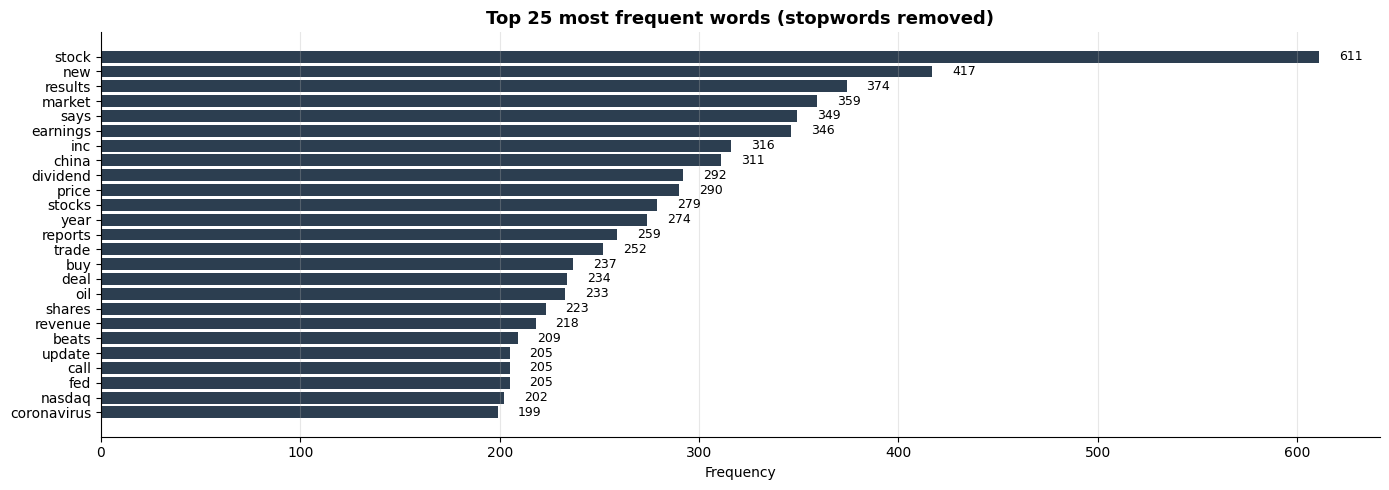

In [186]:
top25_words, top25_counts = zip(*top50[:25])
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_title('Top 25 most frequent words (stopwords removed)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-5'></a>
### 2.5 Top Words per Class (Relative Frequency)

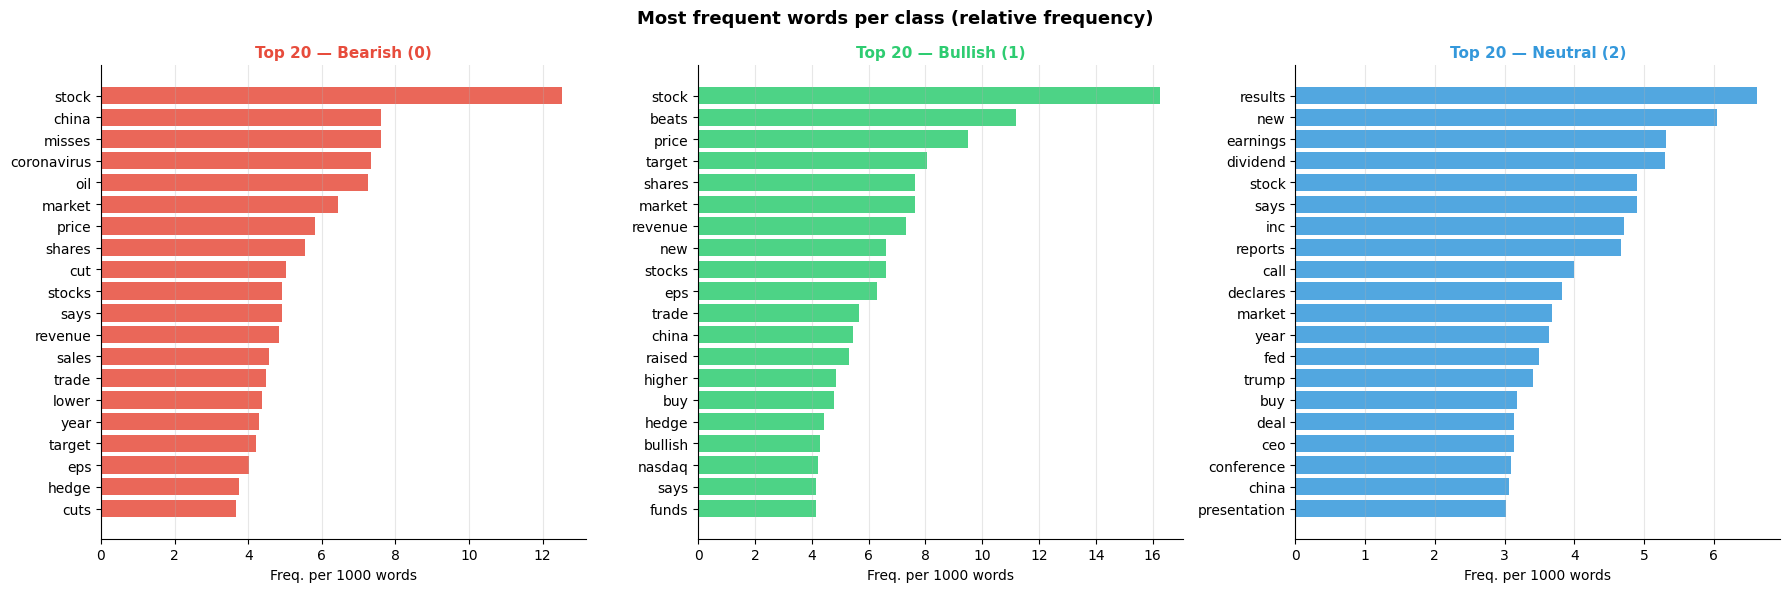

In [187]:
tokens_per_class = {}
for lbl in [0,1,2]:
    toks = []
    for txt in df[df['label']==lbl]['text']:
        toks.extend(tokenize_explore(txt))
    tokens_per_class[lbl] = Counter(toks)

total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0,1,2], axes):
    rel = {w: cnt/total_per_class[lbl]*1000
           for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top = sorted(rel, key=rel.get, reverse=True)[:20]
    ax.barh(list(reversed(top)), [rel[w] for w in reversed(top)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. per 1000 words'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Most frequent words per class (relative frequency)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-6'></a>
### 2.6 Financial Sentiment Words

Verifies that financial sentiment keywords appear in the expected class, confirming dataset coherence and that these words will be good features.

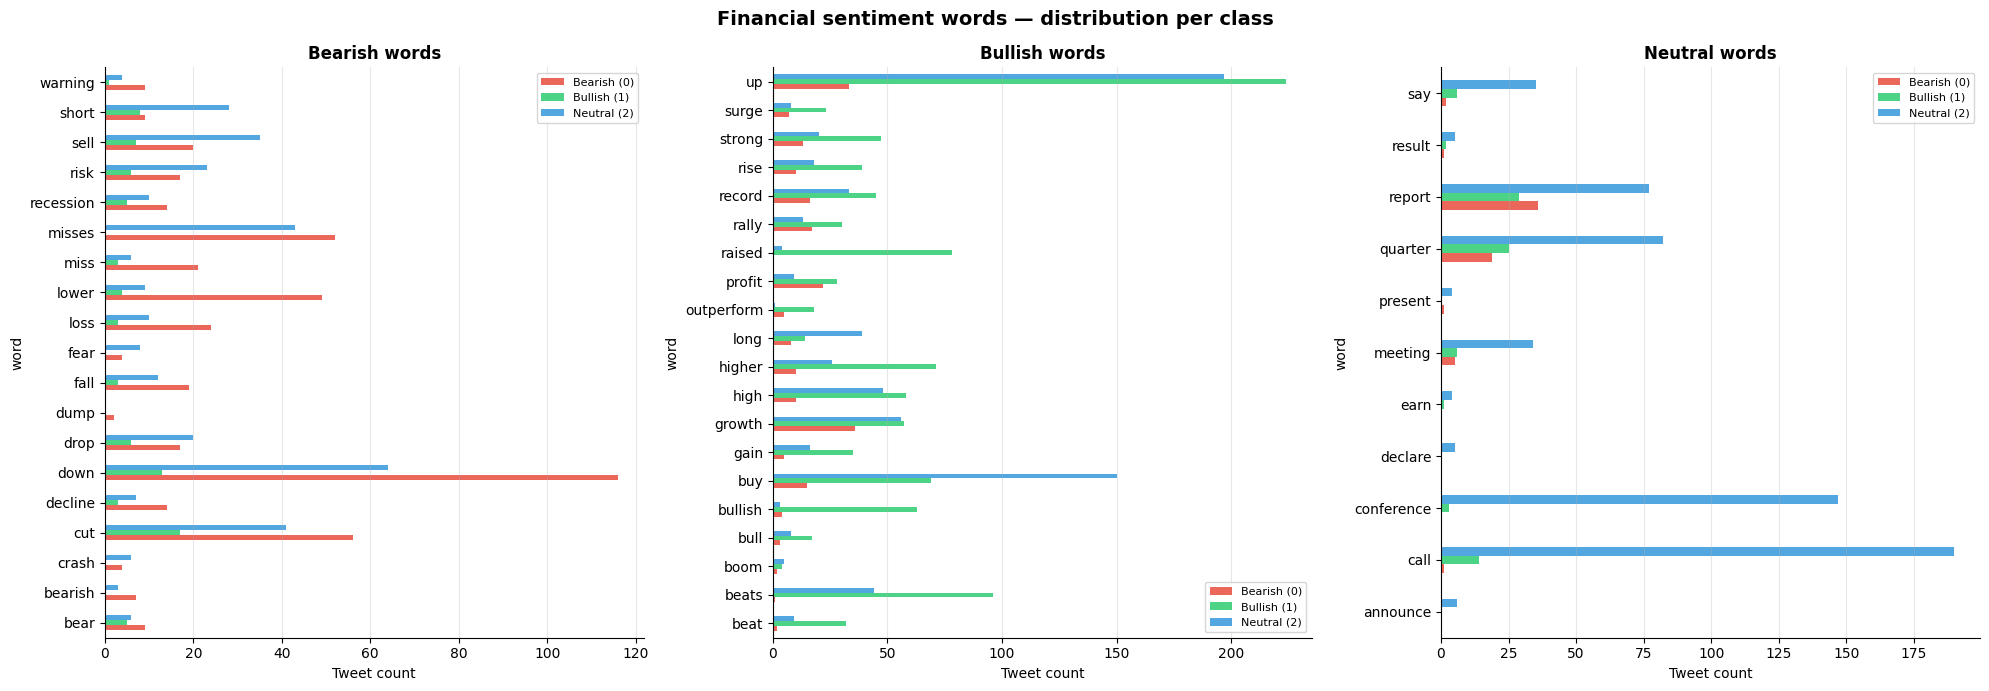

CONCLUSION: Bearish words should dominate class 0, Bullish words class 1.
If confirmed → dataset is coherent and these words will be strong features.


In [188]:
financial_words = {
    'Bearish': ['bear','bearish','crash','dump','fall','drop','loss',
                'decline','miss','misses','cut','lower','down','sell',
                'short','recession','fear','risk','warning'],
    'Bullish': ['bull','bullish','rally','rise','gain','surge','high',
                'beat','beats','raised','higher','buy','long','growth',
                'profit','record','boom','up','strong','outperform'],
    'Neutral': ['report','result','earn','announce','declare','say',
                'conference','meeting','call','present','quarter']
}

results = []
for category, words in financial_words.items():
    for word in words:
        for lbl in [0,1,2]:
            count = df[df['label']==lbl]['text'].str.lower().str.contains(
                rf'\b{word}\b', regex=True).sum()
            results.append({'category':category,'word':word,
                            'class':CLASS_NAMES[lbl],'count':count})
res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (category, color) in zip(axes, [('Bearish','#e74c3c'),('Bullish','#2ecc71'),('Neutral','#3498db')]):
    cat_df = res_df[res_df['category']==category]
    pivot  = cat_df.pivot(index='word', columns='class', values='count').fillna(0)
    pivot.plot(kind='barh', ax=ax, color=[CLASS_COLORS[0],CLASS_COLORS[1],CLASS_COLORS[2]],
               edgecolor='none', alpha=0.85)
    ax.set_title(f'{category} words', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tweet count'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False); ax.legend(fontsize=8)
plt.suptitle('Financial sentiment words — distribution per class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('CONCLUSION: Bearish words should dominate class 0, Bullish words class 1.')
print('If confirmed → dataset is coherent and these words will be strong features.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-7'></a>
### 2.7 N-gram Analysis (Bigrams & Trigrams)

Bigrams like *"beats earnings"* (Bullish) or *"misses estimates"* (Bearish) are not captured by unigrams alone. This analysis directly informs the `ngram_range` parameter in TF-IDF.

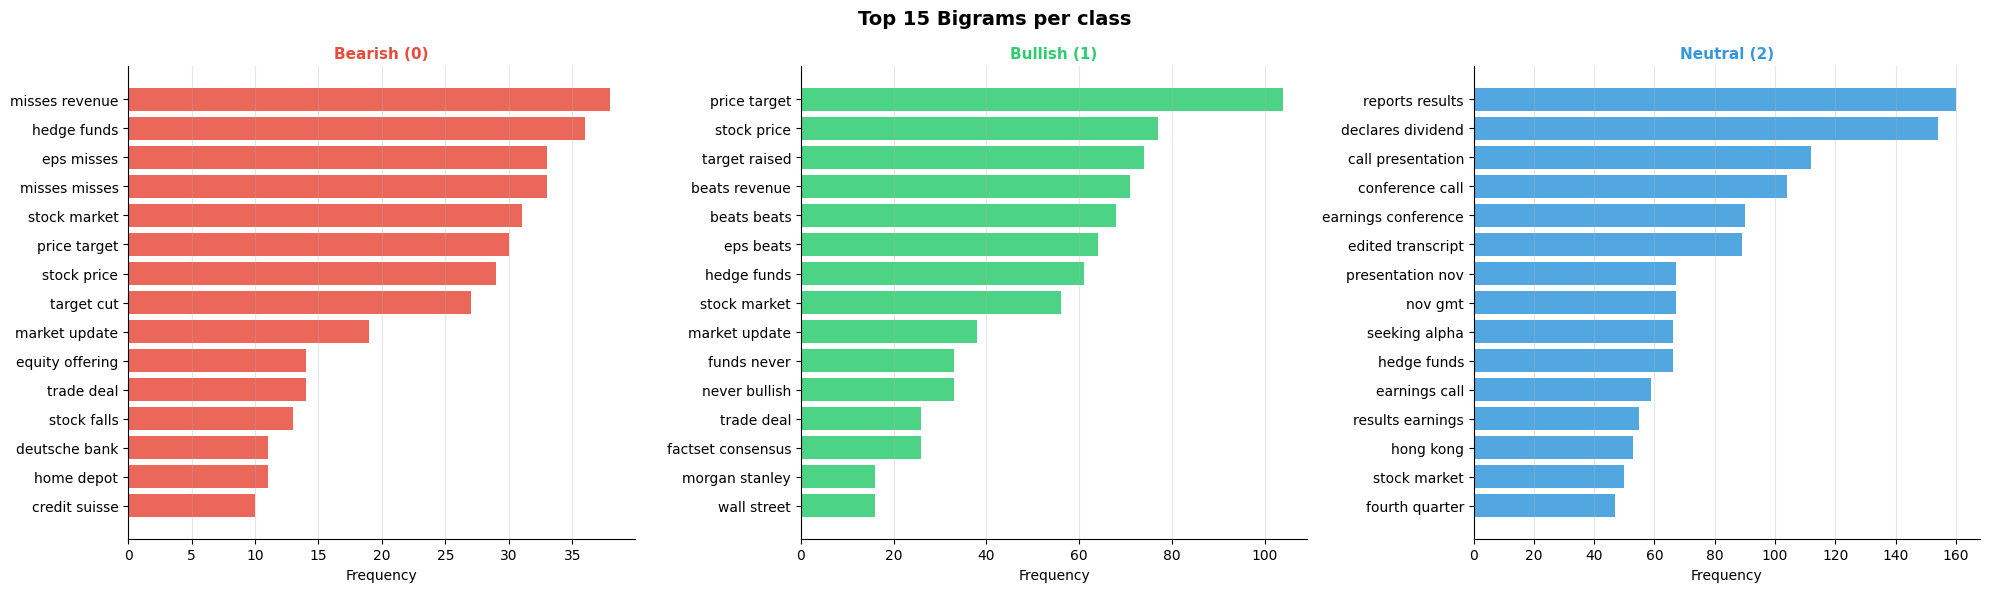

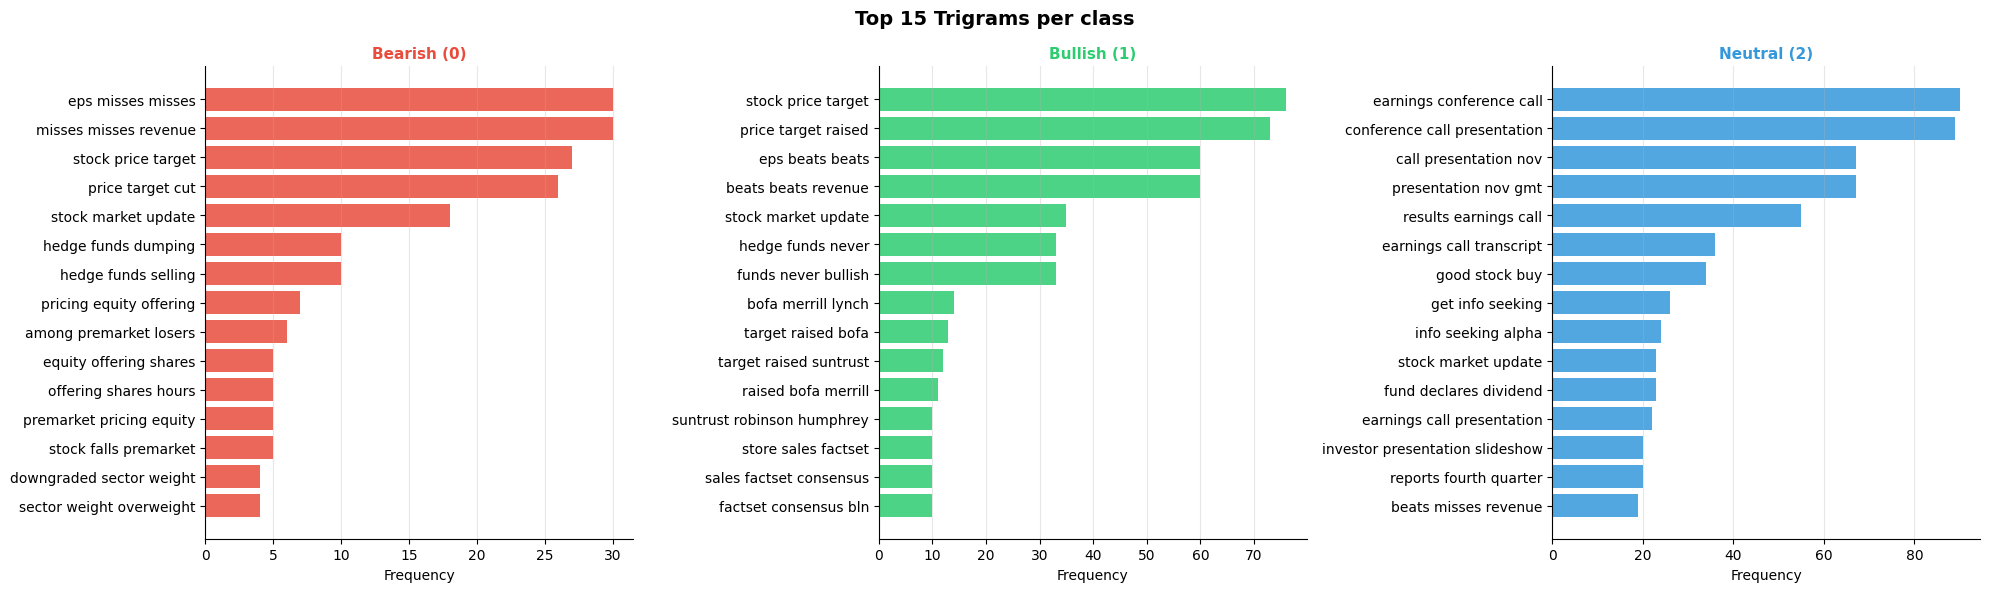

CONCLUSION: If bigrams like "beats earnings" appear in Bullish → use ngram_range=(1,2) in TF-IDF.


In [189]:
def get_ngrams(texts, n):
    all_ng = []
    for text in texts:
        tokens = tokenize_explore(text)
        all_ng.extend([' '.join(g) for g in ngrams(tokens, n)])
    return Counter(all_ng)

for n, label_n in [(2,'Bigrams'),(3,'Trigrams')]:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for lbl, ax in zip([0,1,2], axes):
        ng  = get_ngrams(df[df['label']==lbl]['text'], n)
        top = ng.most_common(15)
        if top:
            words, counts = zip(*top)
            ax.barh(list(reversed(words)), list(reversed(counts)),
                    color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
        ax.set_title(CLASS_NAMES[lbl], fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
        ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    plt.suptitle(f'Top 15 {label_n} per class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
print('CONCLUSION: If bigrams like "beats earnings" appear in Bullish → use ngram_range=(1,2) in TF-IDF.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-8'></a>
### 2.8 Special Features (Hashtags, Mentions, URLs, Numbers)

=== Average presence per tweet ===
  n_hashtags     : 0.23 (max: 7)
  n_mentions     : 0.04 (max: 8)
  n_urls         : 0.53 (max: 3)
  n_numbers      : 0.50 (max: 12)
  Tweets with cashtag: 1,429 (15.0%)

=== Average per class ===
             n_hashtags  n_mentions  n_urls  n_numbers
Bearish (0)        0.17        0.02    0.51       0.53
Bullish (1)        0.16        0.02    0.44       0.74
Neutral (2)        0.27        0.05    0.57       0.42


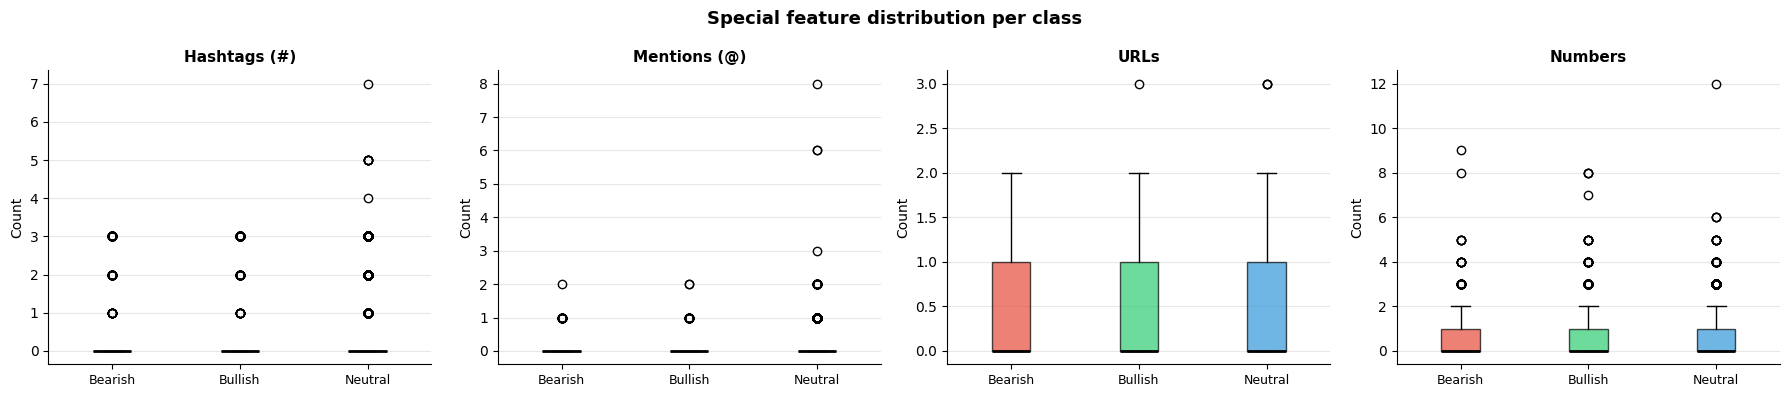

In [190]:
df['n_hashtags']  = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['n_mentions']  = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['n_urls']      = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['n_numbers']   = df['text'].apply(lambda x: len(re.findall(r'\b\d+\.?\d*%?\b', str(x))))
df['has_cashtag'] = df['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', str(x))))

print('=== Average presence per tweet ===')
for feat in ['n_hashtags','n_mentions','n_urls','n_numbers']:
    print(f'  {feat:<15}: {df[feat].mean():.2f} (max: {df[feat].max()})')
print(f'  Tweets with cashtag: {df["has_cashtag"].sum():,} ({df["has_cashtag"].mean()*100:.1f}%)')
print('\n=== Average per class ===')
feat_by_class = df.groupby('label')[['n_hashtags','n_mentions','n_urls','n_numbers']].mean().round(2)
feat_by_class.index = [CLASS_NAMES[i] for i in feat_by_class.index]
print(feat_by_class)

features    = ['n_hashtags','n_mentions','n_urls','n_numbers']
feat_labels = ['Hashtags (#)','Mentions (@)','URLs','Numbers']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for feat, flabel, ax in zip(features, feat_labels, axes):
    data = [df[df['label']==lbl][feat].values for lbl in [0,1,2]]
    bp = ax.boxplot(data, patch_artist=True, medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl]); patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish','Bullish','Neutral'], fontsize=9)
    ax.set_title(flabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Special feature distribution per class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-8b'></a>
### 2.8b Uppercase Analysis

Words written in ALL CAPS in financial tweets are often used for emphasis (e.g. *"CRASH"*, *"PUMP"*). If Bearish tweets use significantly more caps words, lowercasing would discard a useful signal.


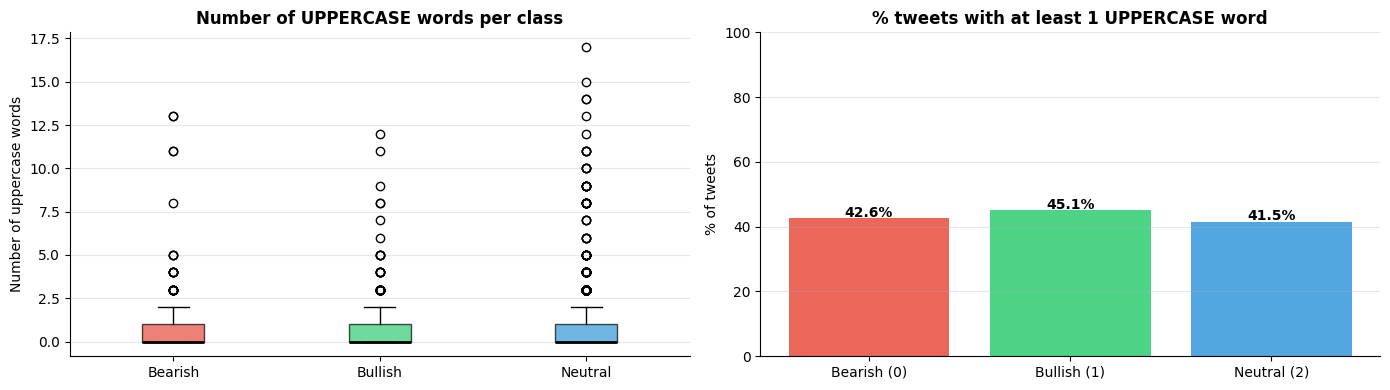

Kruskal-Wallis test: statistic=4.52  p-value=0.1042
→ No significant difference. We can safely apply lowercase without losing relevant information.


In [191]:
# Uppercase analysis per class
df_caps = pd.read_csv('train.csv')

# Remove cashtags first so tickers ($TSLA) don't inflate the caps count
df_caps['text_no_cashtag'] = df_caps['text'].str.replace(r'\$[A-Za-z]{1,5}', ' ', regex=True)

df_caps['n_caps_words'] = df_caps['text_no_cashtag'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
)
df_caps['n_caps_chars'] = df_caps['text_no_cashtag'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper())
)
df_caps['pct_caps_words'] = df_caps.apply(
    lambda row: row['n_caps_words'] / max(len(str(row['text_no_cashtag']).split()), 1) * 100,
    axis=1
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot — Number of UPPERCASE words per class
data_caps = [df_caps[df_caps['label'] == lbl]['n_caps_words'].values for lbl in [0, 1, 2]]
bp = axes[0].boxplot(data_caps, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
for patch, lbl in zip(bp['boxes'], [0, 1, 2]):
    patch.set_facecolor(CLASS_COLORS[lbl])
    patch.set_alpha(0.7)
axes[0].set_xticklabels(['Bearish', 'Bullish', 'Neutral'])
axes[0].set_title('Number of UPPERCASE words per class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of uppercase words')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# % of tweets with at least 1 uppercase word
pct_with_caps = df_caps.groupby('label').apply(
    lambda g: (g['n_caps_words'] > 0).mean() * 100
).rename(index=CLASS_NAMES)

bars = axes[1].bar(pct_with_caps.index, pct_with_caps.values,
                   color=[CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]],
                   edgecolor='none', alpha=0.85)
for bar, val in zip(bars, pct_with_caps.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('% tweets with at least 1 UPPERCASE word', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of tweets')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

groups_caps = [df_caps[df_caps['label'] == lbl]['n_caps_words'] for lbl in [0, 1, 2]]
stat_caps, p_caps = stats.kruskal(*groups_caps)
print(f'Kruskal-Wallis test: statistic={stat_caps:.2f}  p-value={p_caps:.4f}')

if p_caps < 0.05:
    print('→ Significant difference! Uppercase words might be a useful feature — consider NOT applying lowercase.')
else:
    print('→ No significant difference. We can safely apply lowercase without losing relevant information.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-8c'></a>
### 2.8c Mention (@) Analysis

If @mentions like `@elonmusk` appear predominantly in Bullish tweets and others in Bearish, they carry sentiment signal. If the same handles appear across all classes, removing them reduces noise.


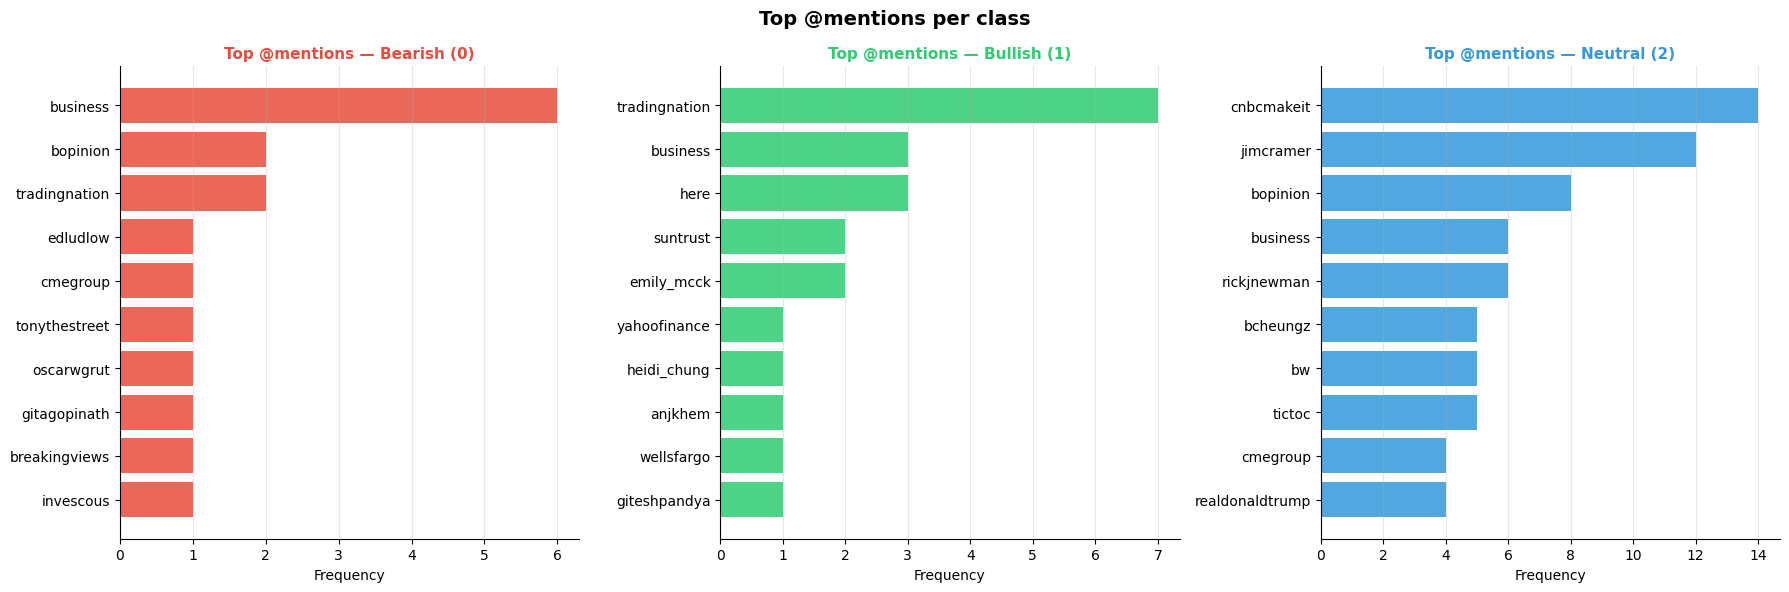

In [192]:
# @Mentions per class 
df_ment = pd.read_csv('train.csv')

def get_mentions(text):
    return re.findall(r'@(\w+)', str(text).lower())

df_ment['mentions']    = df_ment['text'].apply(get_mentions)
df_ment['n_mentions2'] = df_ment['mentions'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset = df_ment[df_ment['label'] == lbl]['mentions']
    all_m  = [m for ms in subset for m in ms]
    top    = Counter(all_m).most_common(10)
    
    if top:
        words_m, counts_m = zip(*top)
        ax.barh(list(reversed(words_m)), list(reversed(counts_m)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
                
    ax.set_title(f'Top @mentions — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Top @mentions per class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




[↑ Back to TOC](#toc)

<a class='anchor' id='2-8d'></a>
### 2.8d Hashtag (#) Deep-Dive

Hashtags like `#bullish` or `#crash` can be strong sentiment signals. We segment compound hashtags (e.g. `#stockmarketcrash` → `stock market crash`) to evaluate whether their internal words differ across classes.


 Examples of hashtag segmentation
  Original  : ['samp', 'economy', 'marketscreener']
  Segmented : ['samp', 'economy', 'market', 'screener']

  Original  : ['bankofnovascotia']
  Segmented : ['bank', 'of', 'nova', 'scotia']

  Original  : ['fedreport', 'economy']
  Segmented : ['fed', 'report', 'economy']

  Original  : ['economy', 'marketscreener']
  Segmented : ['economy', 'market', 'screener']

  Original  : ['imfblog']
  Segmented : ['imf', 'blog']

  Original  : ['economy', 'marketscreener']
  Segmented : ['economy', 'market', 'screener']



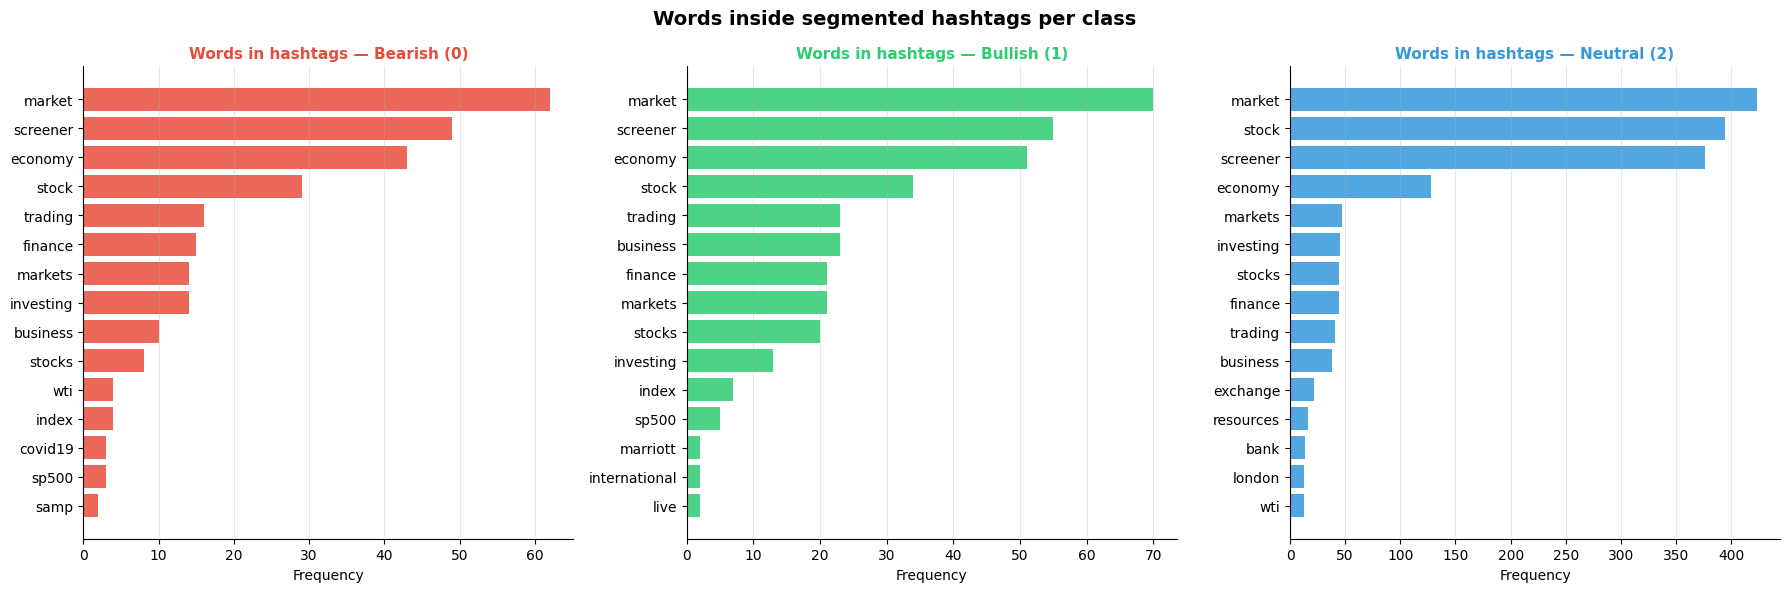

In [193]:
!pip install wordsegment -q
from wordsegment import load as ws_load, segment as ws_segment
ws_load()

df_hash = pd.read_csv('train.csv')

def get_hashtag_words(text):
    hashtags = re.findall(r'#(\w+)', str(text).lower())
    words_h  = []
    for tag in hashtags:
        words_h.extend(ws_segment(tag))
    return words_h

df_hash['hashtag_words'] = df_hash['text'].apply(get_hashtag_words)
df_hash['n_hashtags2']   = df_hash['text'].apply(lambda x: len(re.findall(r'#(\w+)', str(x))))

# Examples
print(' Examples of hashtag segmentation')
mask_h = df_hash['n_hashtags2'] > 0
for _, row in df_hash[mask_h].head(6).iterrows():
    raw = re.findall(r'#(\w+)', str(row['text']).lower())
    print(f'  Original  : {raw}')
    print(f'  Segmented : {row["hashtag_words"]}')
    print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset_h  = df_hash[df_hash['label'] == lbl]['hashtag_words']
    all_words_h = [w for ws in subset_h for w in ws if len(w) > 2]
    top_h     = Counter(all_words_h).most_common(15)
    
    if top_h:
        words_h, counts_h = zip(*top_h)
        ax.barh(list(reversed(words_h)), list(reversed(counts_h)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
                
    ax.set_title(f'Words in hashtags — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Words inside segmented hashtags per class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-8e'></a>
### 2.8e Emoji Analysis

Emojis like 🚀 (Bullish) or 📉 (Bearish) can carry strong sentiment. If their distribution differs across classes, we should convert them to text tokens instead of removing them.


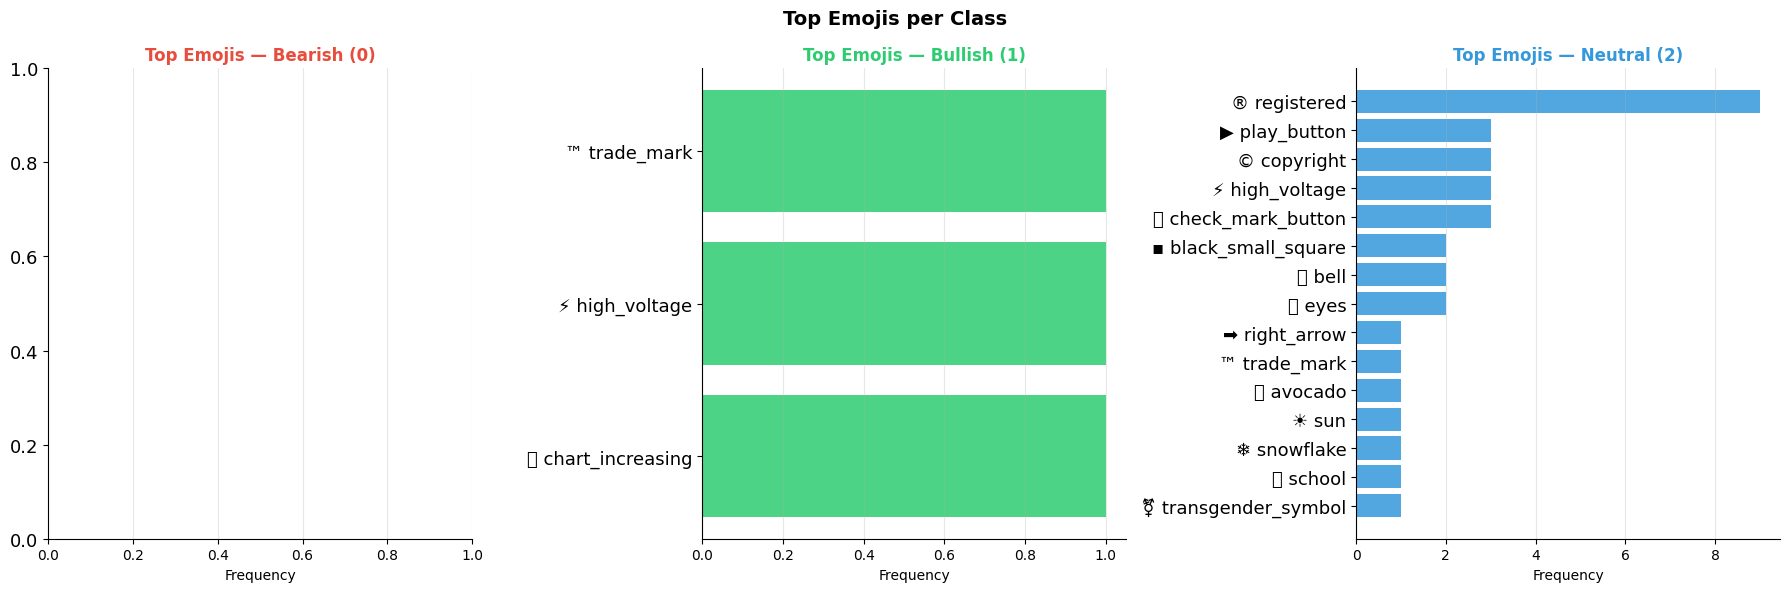

In [194]:
!pip install emoji -q
import emoji
from collections import Counter
import matplotlib.pyplot as plt

df_emj = pd.read_csv('train.csv')

def extract_emojis(text):
    return [ch for ch in str(text) if ch in emoji.EMOJI_DATA]

df_emj['emojis']   = df_emj['text'].apply(extract_emojis)

# ── Create the 3 plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    subset_e = df_emj[df_emj['label'] == lbl]['emojis']
    all_emj  = [e for es in subset_e for e in es]
    top_e    = Counter(all_emj).most_common(15) # Top 15 emojis
    
    if top_e:
        emjs, counts = zip(*top_e)
        
        # To prevent Matplotlib from showing squares instead of the emoji, 
        # we append the text name to the emoji itself (e.g., 🚀 rocket)
        safe_labels = [f"{e} {emoji.demojize(e).replace(':', '')}" for e in emjs]
        
        ax.barh(list(reversed(safe_labels)), list(reversed(counts)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
                
    ax.set_title(f'Top Emojis — {CLASS_NAMES[lbl]}',
                 fontsize=12, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Slightly increase Y-axis font size to make emojis more visible
    ax.tick_params(axis='y', labelsize=13)

plt.suptitle('Top Emojis per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-8f'></a>
### 2.8f Special Characters (+ − ! ? < >)

Punctuation like `!` and `?` may signal strong sentiment. We analyse whether their frequency differs across classes before deciding to remove them in the regex preprocessing step.


=== Statistical Significance (Kruskal-Wallis) ===
Symbol               | p-value    | Significance
--------------------------------------------------
exclamation (!)      | 0.0182     | * (Significant)
question (?)         | 0.0000     | *** (Highly Significant)
plus (+)             | 0.0000     | *** (Highly Significant)
minus/dash (-)       | 0.0032     | ** (Very Significant)
less than (<)        | 1.0000     | ns  (Not Significant)
greater than (>)     | 1.0000     | ns  (Not Significant)
percent (%)          | 0.0000     | *** (Highly Significant)
equals (=)           | 0.1379     | ns  (Not Significant)
asterisk (*)         | 0.4167     | ns  (Not Significant)
ampersand (&)        | 0.0000     | *** (Highly Significant)
dollar ($)           | 0.0000     | *** (Highly Significant)
tilde (~)            | 0.6989     | ns  (Not Significant)


<Axes: title={'center': '% of Tweets Containing Special Characters per Class'}, ylabel='Percentage (%)'>

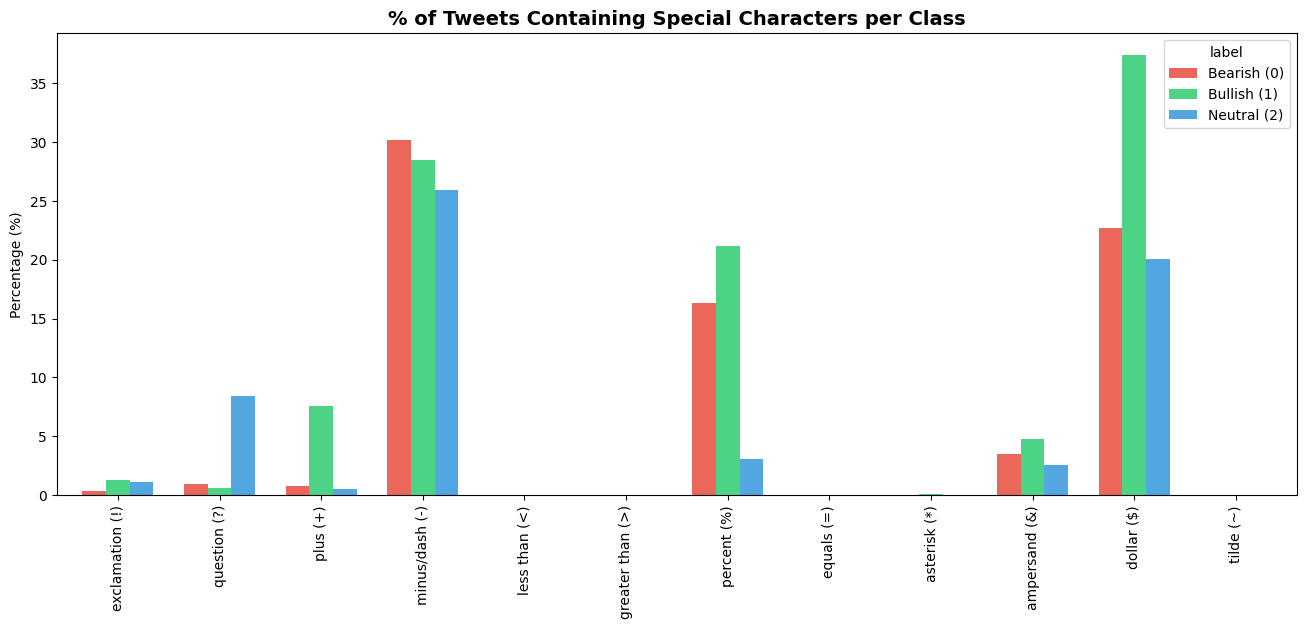

In [195]:

df_sp = pd.read_csv('train.csv')

SPECIAL_CHARS = {
    'exclamation (!)' : r'!',
    'question (?)'    : r'\?',
    'plus (+)'        : r'\+',
    'minus/dash (-)'  : r'-',
    'less than (<)'   : r'<',
    'greater than (>)' : r'>',
    'percent (%)'     : r'%',
    'equals (=)'      : r'=',
    'asterisk (*)'    : r'\*',
    'ampersand (&)'   : r'&',
    'dollar ($)'      : r'\$',
    'tilde (~)'       : r'~'
}

# 1. Count occurrences
char_cols = []
for name, pat in SPECIAL_CHARS.items():
    col = name.split(' ')[0].replace('/', '_') + '_count'
    df_sp[col] = df_sp['text'].apply(lambda x: len(re.findall(pat, str(x))))
    char_cols.append(col)

# 2. Calculate % of tweets with at least 1 occurrence
pct_sp = df_sp.groupby('label')[char_cols].apply(lambda x: (x > 0).mean() * 100).rename(index=CLASS_NAMES)
pct_sp.columns = list(SPECIAL_CHARS.keys())

# 3. Calculate p-values (Kruskal-Wallis test across the 3 classes)
print('=== Statistical Significance (Kruskal-Wallis) ===')
print(f"{'Symbol':<20} | {'p-value':<10} | {'Significance'}")
print("-" * 50)

p_values = {}
for col, name in zip(char_cols, SPECIAL_CHARS.keys()):
    groups = [df_sp[df_sp['label'] == lbl][col] for lbl in [0, 1, 2]]
    
    # FIX: Check if all values in the column are identical (e.g., all zeros)
    if df_sp[col].nunique() <= 1:
        p_val = 1.0  # Force p-value to 1.0 (Not Significant)
    else:
        try:
            stat, p_val = stats.kruskal(*groups)
        except ValueError:
            p_val = 1.0
            
    p_values[name] = p_val
    
    # Add visual markers for quick reading
    if p_val < 0.001:   sig = '*** (Highly Significant)'
    elif p_val < 0.01:  sig = '** (Very Significant)'
    elif p_val < 0.05:  sig = '* (Significant)'
    else:               sig = 'ns  (Not Significant)'
        
    print(f"{name:<20} | {p_val:<10.4f} | {sig}")

# 4. Plotting the single bar chart
fig, ax = plt.subplots(figsize=(16, 6))
color_list = [CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]]

pct_sp.T.plot(kind='bar', ax=ax, color=color_list, width=0.7, edgecolor='none', alpha=0.85)

ax.set_title('% of Tweets Containing Special Characters per Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax

[↑ Back to TOC](#toc)

<a class='anchor' id='2-9'></a>
### 2.9 Top Hashtags & Cashtags per Class

If the same tickers appear across all classes → normalise to `TICKER`. If some are exclusive to one class → they may be useful features.

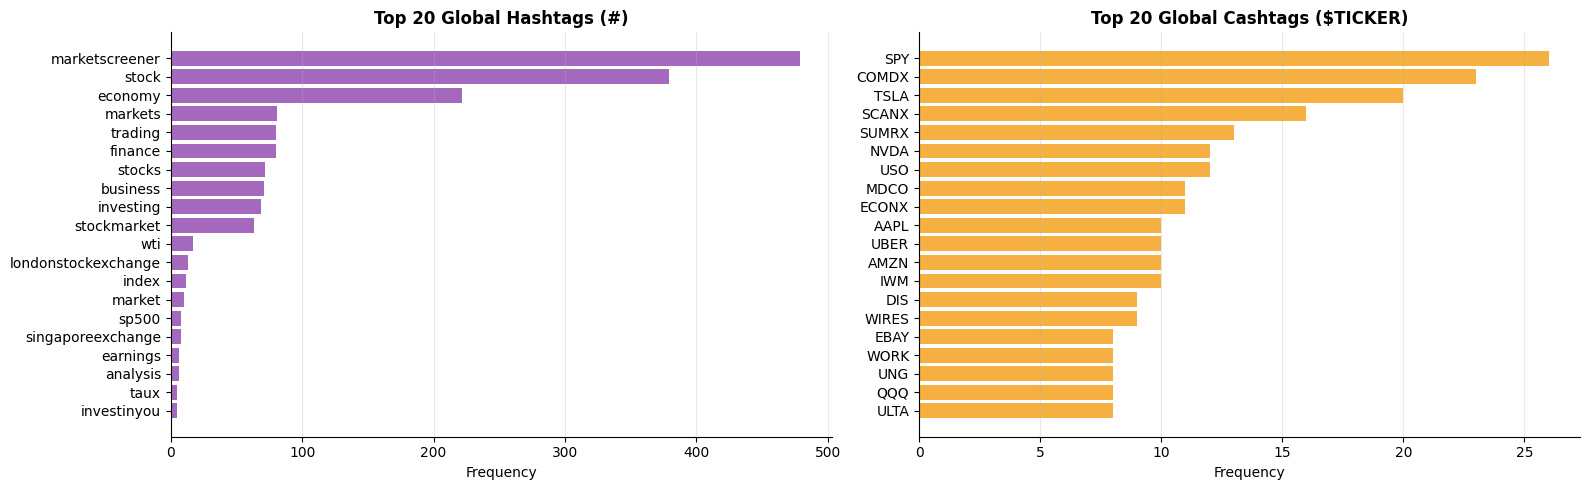

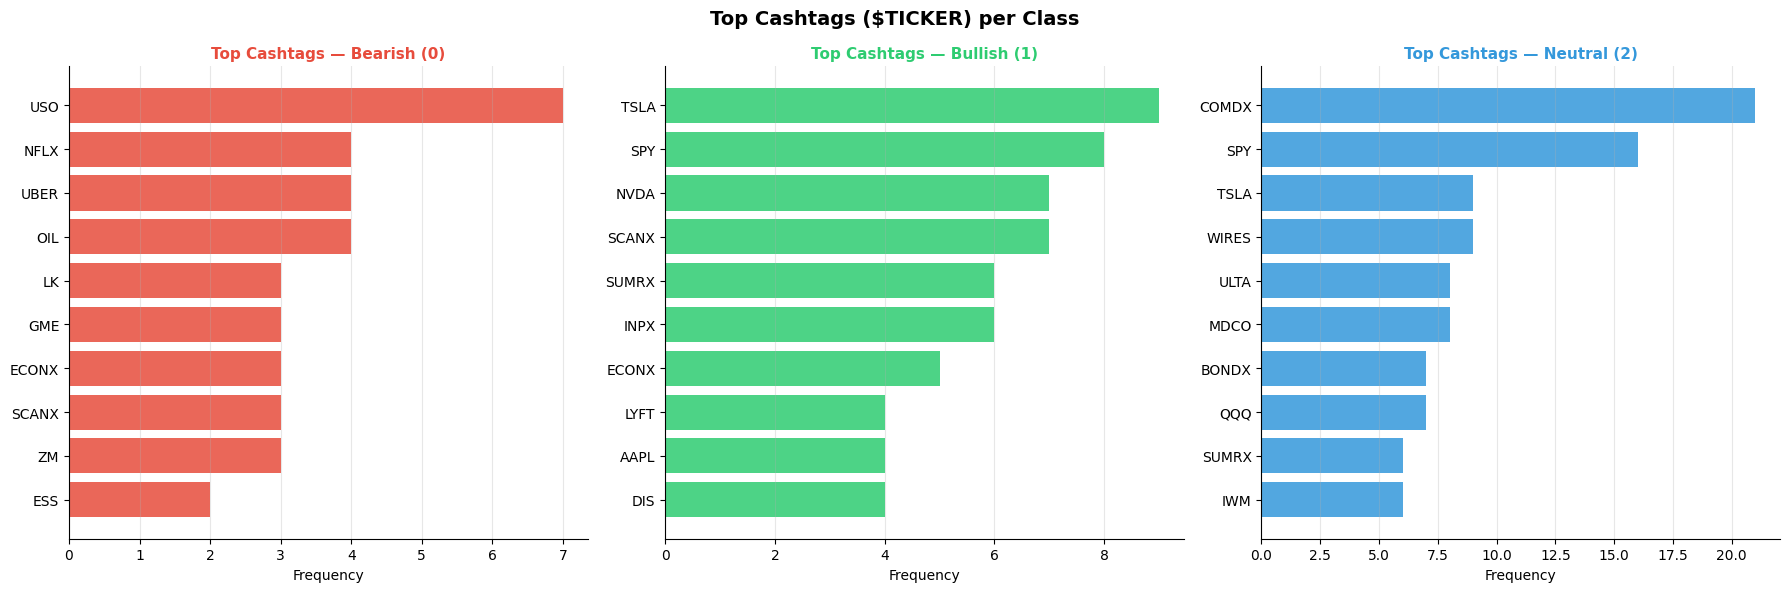

In [196]:

### 2.9 Top Hashtags & Cashtags per Class

df_original = pd.read_csv('train.csv')

# ── 1. Global Extraction ─────────────────────────────────────────────────────
all_hashtags = []
for txt in df_original['text']:
    all_hashtags.extend(re.findall(r'#(\w+)', str(txt).lower()))
top_hashtags = Counter(all_hashtags).most_common(20)

def get_cashtags(text):
    return re.findall(r'\$([A-Za-z]{1,5})', str(text).upper())

df_original['cashtags']   = df_original['text'].apply(get_cashtags)
df_original['n_cashtags'] = df_original['cashtags'].str.len()

all_cashtags_raw = [c for cashtags in df_original['cashtags'] for c in cashtags]
top_cashtags = Counter(all_cashtags_raw).most_common(20)

# Global Visualisation (1x2 Plot)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
if top_hashtags:
    wh, ch = zip(*top_hashtags)
    axes[0].barh(list(reversed(wh)), list(reversed(ch)),
                 color='#8e44ad', edgecolor='none', alpha=0.8)
    axes[0].set_title('Top 20 Global Hashtags (#)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Frequency'); axes[0].grid(axis='x', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)
    
if top_cashtags:
    wc, cc = zip(*top_cashtags)
    axes[1].barh(list(reversed(wc)), list(reversed(cc)),
                 color='#f39c12', edgecolor='none', alpha=0.8)
    axes[1].set_title('Top 20 Global Cashtags ($TICKER)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequency'); axes[1].grid(axis='x', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


# Class-specific Visualisation (1x3 Plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset   = df_original[df_original['label'] == lbl]['cashtags']
    all_cash = [c for cashtags in subset for c in cashtags]
    top      = Counter(all_cash).most_common(10)
    
    if top:
        words, counts = zip(*top)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
                
    ax.set_title(f'Top Cashtags — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Top Cashtags ($TICKER) per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




[↑ Back to TOC](#toc)

<a class='anchor' id='2-10'></a>
### 2.10 Tweets with Little Content After Cleaning

Tweets that become empty or have fewer than 3 tokens after cleaning are problematic for models — important to identify them now.

Empty tweets after cleaning (0 tokens): 10
Tweets with fewer than 3 tokens:        156
Tweets with useful content (≥3 tokens): 9,387


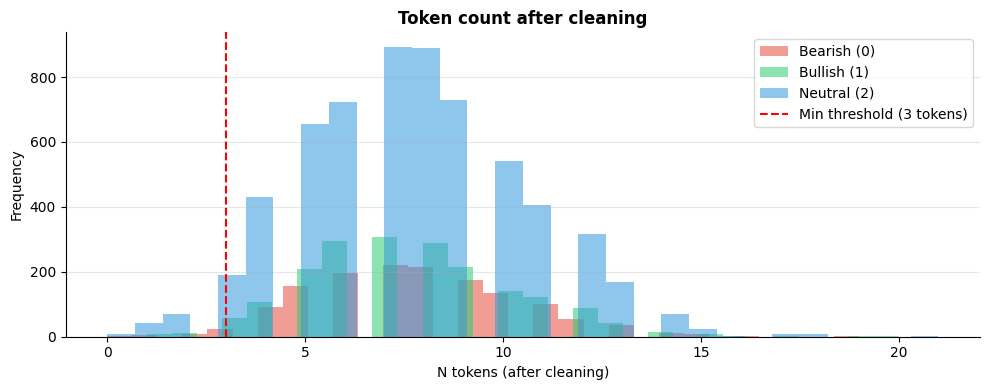


Sample of short/empty tweets:
                                                                                                                        text  label  n_tokens_clean
6                                                                              $GM - GM loses a bull https://t.co/tdUfG5HbXy      0               2
654                                        QE Infinity: So It Begins. https://t.co/HppY8KK3fV #business #stocks #stockmarket      2               2
1119                                                                        $LK calls @BlackBox_Team https://t.co/f0cvVLxwvW      2               1
1192                     AbbVie : Form 8.3 -  #AbbVie #Stock #MarketScreener https://t.co/QPZhKPWGjF https://t.co/AS7H0SkVG8      2               2
1612  JEOL : Form 8.3 - https://t.co/erBSsYuL00 #JEOL #Stock #MarketScreener https://t.co/Lt8CXiXJDy https://t.co/yVehgWa695      2               2
1692                     MongoDB : Form 10-Q #MongoDB #Stock #MarketScreener http

In [197]:
df['tokens_clean']   = df['text'].apply(tokenize_explore)
df['n_tokens_clean'] = df['tokens_clean'].str.len()

empty        = (df['n_tokens_clean'] == 0).sum()
short_tweets = (df['n_tokens_clean'] < 3).sum()

print(f'Empty tweets after cleaning (0 tokens): {empty}')
print(f'Tweets with fewer than 3 tokens:        {short_tweets}')
print(f'Tweets with useful content (≥3 tokens): {(df["n_tokens_clean"] >= 3).sum():,}')

fig, ax = plt.subplots(figsize=(10, 4))
for lbl in [0,1,2]:
    ax.hist(df[df['label']==lbl]['n_tokens_clean'], bins=30, alpha=0.55,
            color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Min threshold (3 tokens)')
ax.set_title('Token count after cleaning', fontsize=12, fontweight='bold')
ax.set_xlabel('N tokens (after cleaning)'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

if short_tweets > 0:
    mask = df['n_tokens_clean'] < 3
    print('\nSample of short/empty tweets:')
    print(df[mask][['text','label','n_tokens_clean']].head(10).to_string())

[↑ Back to TOC](#toc)

<a class='anchor' id='2-11'></a>
### 2.11 Exclusive Vocabulary per Class

Words that appear in **only one class** are the most discriminative features — directly justifies using TF-IDF with high `max_features`.

=== Exclusive vocabulary per class (top 20) ===

Bearish (0) — 955 exclusive words:
  plunges                   9
  sinks                     8
  tumble                    8
  downgrade                 7
  tumbles                   6
  headwinds                 6
  cymabay                   5
  tumbled                   5
  gamestop                  5
  cashing                   4
  sliding                   4
  lakewood                  4
  hitting                   4
  recalls                   4
  laundering                4
  underperform              4
  slashed                   4
  plummets                  4
  slash                     3
  vulnerable                3

Bullish (1) — 1165 exclusive words:
  climbs                   11
  jumped                    8
  levi                      6
  inpx                      6
  bounces                   5
  hasbro                    5
  intercept                 5
  icpt                      5
  ounce                     5
  ions   

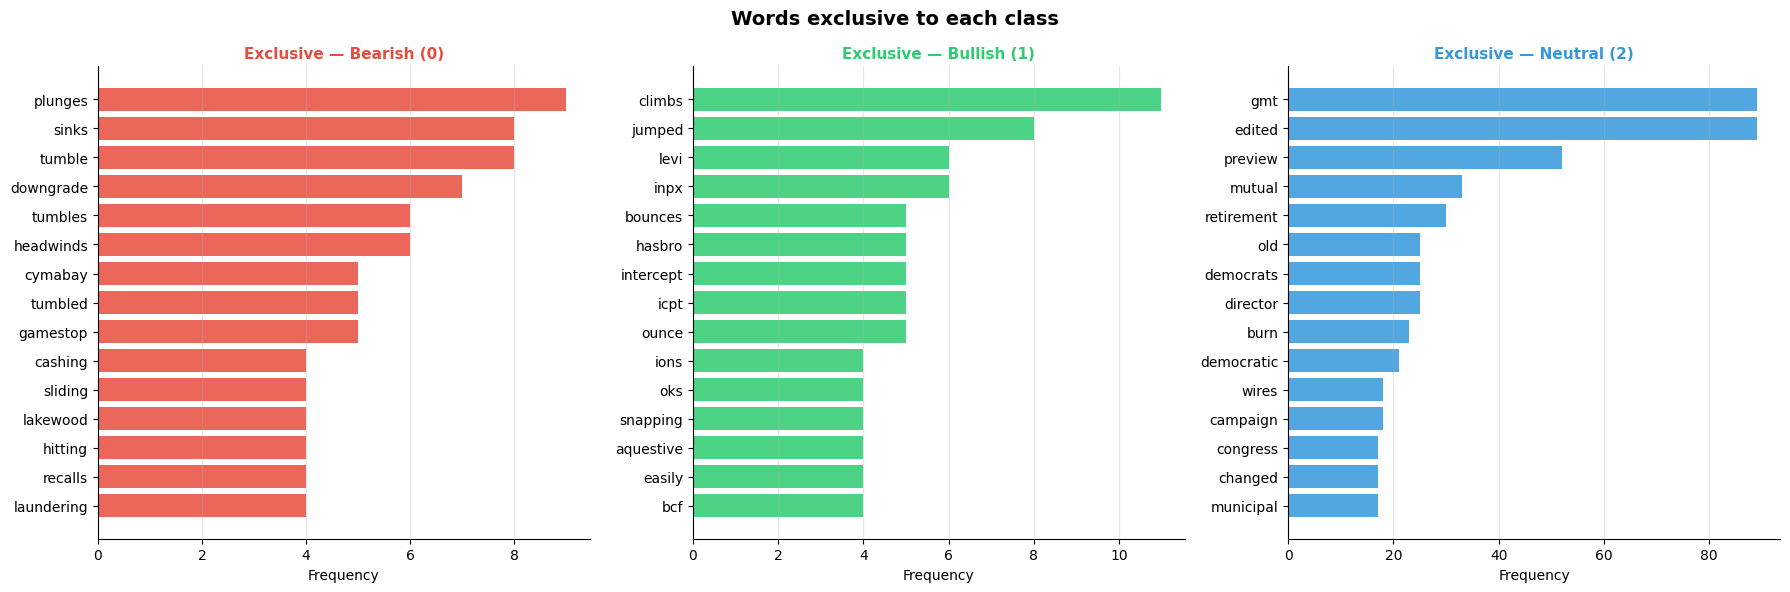

In [198]:
vocab_per_class = {}
freq_per_class  = {}
for lbl in [0,1,2]:
    toks = []
    for txt in df[df['label']==lbl]['text']:
        toks.extend(tokenize_explore(txt))
    vocab_per_class[lbl] = set(toks)
    freq_per_class[lbl]  = Counter(toks)

print('=== Exclusive vocabulary per class (top 20) ===')
for lbl in [0,1,2]:
    others    = set().union(*[vocab_per_class[l] for l in [0,1,2] if l!=lbl])
    exclusive = vocab_per_class[lbl] - others
    top_excl  = sorted(exclusive, key=lambda w: freq_per_class[lbl][w], reverse=True)[:20]
    print(f'\n{CLASS_NAMES[lbl]} — {len(exclusive)} exclusive words:')
    for w in top_excl:
        print(f'  {w:<22} {freq_per_class[lbl][w]:>4}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0,1,2], axes):
    others    = set().union(*[vocab_per_class[l] for l in [0,1,2] if l!=lbl])
    exclusive = vocab_per_class[lbl] - others
    top_excl  = sorted(exclusive, key=lambda w: freq_per_class[lbl][w], reverse=True)[:15]
    counts    = [freq_per_class[lbl][w] for w in top_excl]
    ax.barh(list(reversed(top_excl)), list(reversed(counts)),
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Exclusive — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Words exclusive to each class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='2-12'></a>
### 2.12 Lexical Dispersion

A word that appears 500 times but only in 3 tweets is not a good feature (likely noise). This justifies the `min_df` parameter in TF-IDF.

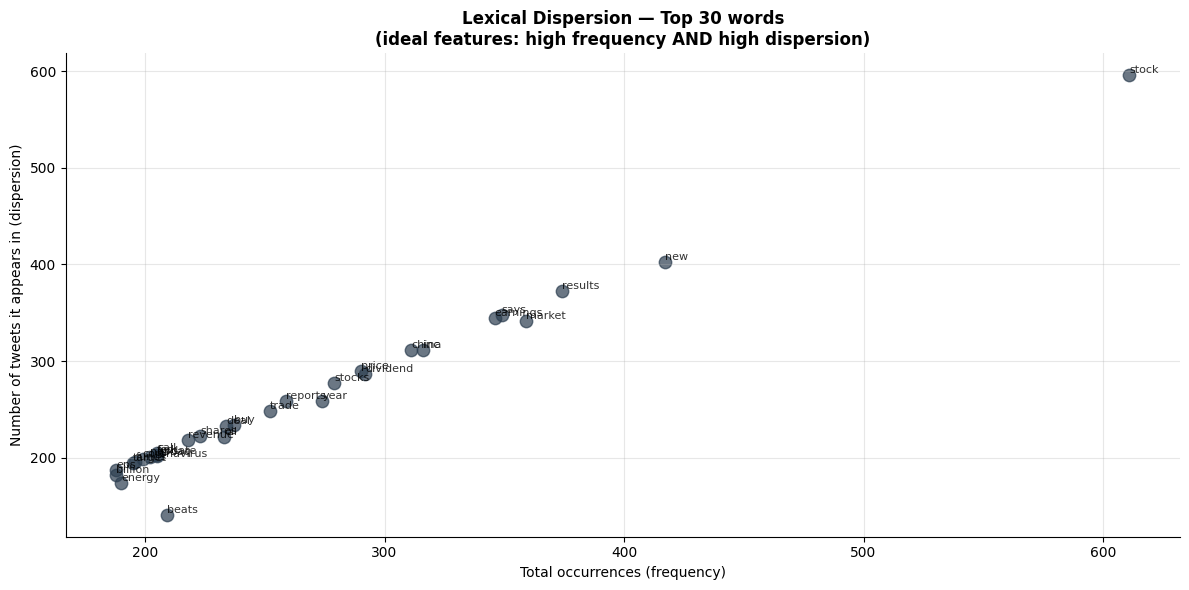

CONCLUSION: Words concentrated in few tweets → set min_df=2 or min_df=3 in TF-IDF/BoW.


In [199]:
word_doc_count = defaultdict(int)
word_total     = Counter()

for text in df['text']:
    tokens_set = set(tokenize_explore(text))
    for t in tokens_set:
        word_doc_count[t] += 1

for text in df['text']:
    word_total.update(tokenize_explore(text))

top30 = [w for w, _ in word_total.most_common(30)]
x_vals = [word_total[w]    for w in top30]
y_vals = [word_doc_count[w] for w in top30]

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(x_vals, y_vals, c='#2c3e50', alpha=0.7, s=80)
for i, word in enumerate(top30):
    ax.annotate(word, (x_vals[i], y_vals[i]),
                fontsize=8, ha='left', va='bottom', alpha=0.8)
ax.set_xlabel('Total occurrences (frequency)')
ax.set_ylabel('Number of tweets it appears in (dispersion)')
ax.set_title('Lexical Dispersion — Top 30 words\n(ideal features: high frequency AND high dispersion)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print('CONCLUSION: Words concentrated in few tweets → set min_df=2 or min_df=3 in TF-IDF/BoW.')

[↑ Back to TOC](#toc)

<a class='anchor' id='2-14'></a>
### 2.14 Tweet Length Boxplot & Statistical Test

If tweet length differs significantly between classes (Kruskal-Wallis p < 0.05), `n_words` can be used as an extra feature.

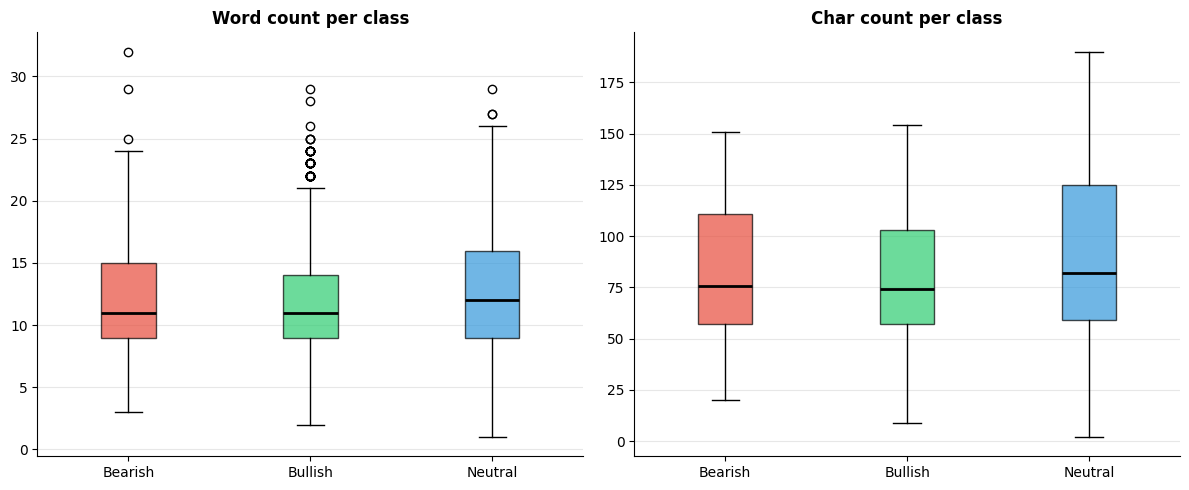

Kruskal-Wallis test (tweet length difference between classes):
  statistic = 8.97   p-value = 0.0113
  → Statistically significant! Tweet length can be used as an extra feature.

Mean word count per class:
label
Bearish (0)    12.0
Bullish (1)    11.9
Neutral (2)    12.3
Name: n_words, dtype: float64


In [201]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for metric, ax, title in [('n_words',axes[0],'Word count per class'),
                            ('n_chars', axes[1],'Char count per class')]:
    data = [df[df['label']==lbl][metric].values for lbl in [0,1,2]]
    bp   = ax.boxplot(data, patch_artist=True, medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'],[0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl]); patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish','Bullish','Neutral'], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

bear = df[df['label']==0]['n_words']
bull = df[df['label']==1]['n_words']
neut = df[df['label']==2]['n_words']
stat, p = stats.kruskal(bear, bull, neut)
print(f'Kruskal-Wallis test (tweet length difference between classes):')
print(f'  statistic = {stat:.2f}   p-value = {p:.4f}')
if p < 0.05:
    print('  → Statistically significant! Tweet length can be used as an extra feature.')
else:
    print('  → No significant difference. Length does not discriminate classes well.')
print('\nMean word count per class:')
print(df.groupby('label')['n_words'].mean().round(1).rename(index=CLASS_NAMES))

[↑ Back to TOC](#toc)

<a class='anchor' id='2-14'></a>
### 2.14 Exploration Summary & Conclusions

In [202]:
print('=' * 65)
print('DATA EXPLORATION SUMMARY')
print('=' * 65)
print(f'Total tweets (train):            {len(df):,}')
print(f'Unique vocabulary (no stopwords):{len(vocab):,} words')
print(f'Total tokens:                    {len(all_tokens):,}')
print(f'Avg tweet length:                {df["n_words"].mean():.1f} words / {df["n_chars"].mean():.0f} chars')
print()
print('Class distribution:')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print()
print(f'Majority-class baseline: {majority_acc:.1f}%')
print()
print('Key findings:')
print('  1. Class imbalance is moderate → use class_weight="balanced"')
print('  2. Financial keywords appear in expected classes → coherent dataset')
print('  3. Bigrams are informative → use ngram_range=(1,2) in TF-IDF')
print('  4. Most cashtags appear across all classes → normalise to TICKER')
print('  5. Lexical dispersion confirms that min_df=2 in TF-IDF is appropriate')
print('=' * 65)

DATA EXPLORATION SUMMARY
Total tweets (train):            9,543
Unique vocabulary (no stopwords):14,016 words
Total tokens:                    73,385
Avg tweet length:                12.2 words / 86 chars

Class distribution:
  Bearish (0): 1,442 (15.1%)
  Bullish (1): 1,923 (20.2%)
  Neutral (2): 6,178 (64.7%)

Majority-class baseline: 64.7%

Key findings:
  1. Class imbalance is moderate → use class_weight="balanced"
  2. Financial keywords appear in expected classes → coherent dataset
  3. Bigrams are informative → use ngram_range=(1,2) in TF-IDF
  4. Most cashtags appear across all classes → normalise to TICKER
  5. Lexical dispersion confirms that min_df=2 in TF-IDF is appropriate


[↑ Back to TOC](#toc)

<a class='anchor' id='3'></a>
---
## 3. Data Preprocessing

Two separate preprocessing pipelines are used:
- **Classical pipeline** (BoW / TF-IDF / Word2Vec + Traditional ML): full cleaning with lemmatization.
- **Transformer pipeline** (BERT / FinBERT / RoBERTa): minimal cleaning only — the tokenizer handles the rest.

**Techniques applied (≥4 required):** Lowercasing · URL removal · @mention removal · Hashtag normalisation · Cashtag normalisation · Non-alpha regex · Stopword removal · Lemmatization · `word_tokenize`

<a class='anchor' id='3-1'></a>
### 3.1 Step-by-step Demonstration

In [203]:
tweet_example = "$TSLA beats earnings! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%"
t = tweet_example
steps = [
    ('1. Original',             t),
    ('2. Lowercase',            t := t.lower()),
    ('3. Remove URLs',          t := re.sub(r'http\S+|www\S+','',t)),
    ('4. Remove @mentions',     t := re.sub(r'@\w+','',t)),
    ('5. Hashtags → words',     t := re.sub(r'#(\w+)',r'\1',t)),
    ('6. Cashtags → ticker',    t := re.sub(r'\$[a-zA-Z]{1,5}','ticker',t)),
    ('7. Letters only (regex)', t := re.sub(r'[^a-zA-Z\s]',' ',t)),
    ('8. Remove stopwords',     t := ' '.join(w for w in t.split() if w not in STOP and len(w)>2)),
    ('9. Lemmatization',        t := ' '.join(lemma.lemmatize(w) for w in t.split())),
]
print('='*70)
for step_name, step_text in steps:
    print(f'{step_name:<30} → {step_text.strip()}')
print('='*70)

1. Original                    → $TSLA beats earnings! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
2. Lowercase                   → $tsla beats earnings! #bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
3. Remove URLs                 → $tsla beats earnings! #bullish #stocks @elonmusk  up 5.3%
4. Remove @mentions            → $tsla beats earnings! #bullish #stocks   up 5.3%
5. Hashtags → words            → $tsla beats earnings! bullish stocks   up 5.3%
6. Cashtags → ticker           → ticker beats earnings! bullish stocks   up 5.3%
7. Letters only (regex)        → ticker beats earnings  bullish stocks   up
8. Remove stopwords            → ticker beats earnings bullish stocks
9. Lemmatization               → ticker beat earnings bullish stock


[↑ Back to TOC](#toc)

<a class='anchor' id='3-2'></a>
### 3.2 Lemmatization vs Stemming

Lemmatization is chosen: it preserves recognisable word forms, crucial for financial text (e.g. *"bullish"* should not become *"bulli"*).

In [204]:
financial_words_cmp = [
    'beats','beating','beaten','misses','missing','missed',
    'earnings','earning','rises','rising','raised',
    'falling','fallen','falls','bullish','bearish','investing','investors',
]
print(f"{'Word':<18} {'Lemma':<18} {'Stem':<18} Notes")
print('-'*70)
for word in financial_words_cmp:
    l = lemma.lemmatize(word)
    s = stemmer.stem(word)
    note = '← different!' if l != s else ''
    print(f'{word:<18} {l:<18} {s:<18} {note}')
print('\nDecision: Lemmatization used in the classical pipeline (use_lemma=True).')

Word               Lemma              Stem               Notes
----------------------------------------------------------------------
beats              beat               beat               
beating            beating            beat               ← different!
beaten             beaten             beaten             
misses             miss               miss               
missing            missing            miss               ← different!
missed             missed             miss               ← different!
earnings           earnings           earn               ← different!
earning            earning            earn               ← different!
rises              rise               rise               
rising             rising             rise               ← different!
raised             raised             rais               ← different!
falling            falling            fall               ← different!
fallen             fallen             fallen             
falls           

[↑ Back to TOC](#toc)

<a class='anchor' id='3-3'></a>
### 3.3 Preprocessing Functions

In [205]:
### 3.3 Preprocessing Functions
from tqdm import tqdm

def preprocess_classical(text_list, use_lemma=True, use_stemmer=False):
    """
    Full text cleaning for classical ML models (BoW / TF-IDF / Word2Vec).
    Steps: lowercase → URLs → @mentions → hashtags → cashtags
           → regex (keep letters AND special chars) → stopwords → word_tokenize → lemmatize.
    """
    results = []
    valid_symbols = set('!?+-%&$')
    
    
    for text in tqdm(text_list, desc='Classical preprocessing'):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#(\w+)', r'\1', text)
        text = re.sub(r'\$[a-zA-Z]{1,5}', 'ticker', text)
        
        text = re.sub(r'[^a-zA-Z\s?+%&!$-]', ' ', text)
        
        tokens = word_tokenize(text)
        
        tokens = [w for w in tokens if w not in STOP and (len(w) > 2 or w in valid_symbols)]
        
        if use_lemma:    tokens = [lemma.lemmatize(w) for w in tokens]
        if use_stemmer:  tokens = [stemmer.stem(w) for w in tokens]
        
        results.append(' '.join(tokens))
    return results

def preprocess_transformer(text_list):
    """
    Minimal cleaning for Transformer models (BERT / FinBERT / RoBERTa).
    """
    results = []
    for text in tqdm(text_list, desc='Transformer preprocessing'):
        text = str(text)
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        results.append(text)
    return results

[↑ Back to TOC](#toc)

<a class='anchor' id='3-4'></a>
### 3.4 Apply to Full Training Set

> **Note on leakage:** `preprocess_classical` and `preprocess_transformer` are deterministic — they learn nothing from the data. They can safely be applied to the full dataset before the CV split. The only operations that must be fitted exclusively on the train fold are vectorisers (TF-IDF, Word2Vec) — these are handled inside `Pipeline` objects in Section 6.

In [206]:
print('Applying classical pipeline (lemmatization)...')
df['text_lemma'] = preprocess_classical(df['text'].tolist(), use_lemma=True, use_stemmer=False)

print('Applying classical pipeline (stemming — for comparison)...')
df['text_stem']  = preprocess_classical(df['text'].tolist(), use_lemma=False, use_stemmer=True)

print('Applying transformer pipeline...')
df['text_transformer'] = preprocess_transformer(df['text'].tolist())

print(f'Columns available: {list(df.columns)}')

Applying classical pipeline (lemmatization)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:00<00:00, 10421.12it/s]


Applying classical pipeline (stemming — for comparison)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:01<00:00, 9129.42it/s]


Applying transformer pipeline...


Transformer preprocessing: 100%|██████████| 9543/9543 [00:00<00:00, 168070.86it/s]

Columns available: ['text', 'label', 'n_chars', 'n_words', 'n_tokens', 'n_hashtags', 'n_mentions', 'n_urls', 'n_numbers', 'has_cashtag', 'tokens_clean', 'n_tokens_clean', 'text_lemma', 'text_stem', 'text_transformer']


[↑ Back to TOC](#toc)

<a class='anchor' id='3-5'></a>
### 3.5 Before / After Comparison

In [207]:
print('Before / after preprocessing — 5 examples:\n')
for i in range(5):
    print(f'[{i}] ORIGINAL    : {df["text"].iloc[i]}')
    print(f'    LEMMA       : {df["text_lemma"].iloc[i]}')
    print(f'    STEM        : {df["text_stem"].iloc[i]}')
    print(f'    TRANSFORMER : {df["text_transformer"].iloc[i]}')
    print()

Before / after preprocessing — 5 examples:

[0] ORIGINAL    : $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
    LEMMA       : ticker - jpmorgan reel expectation beyond meat
    STEM        : ticker - jpmorgan reel expect beyond meat
    TRANSFORMER : $BYND - JPMorgan reels in expectations on Beyond Meat

[1] ORIGINAL    : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
    LEMMA       : ticker ticker - nomura point booking weakness carnival royal caribbean
    STEM        : ticker ticker - nomura point book weak carniv royal caribbean
    TRANSFORMER : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean

[2] ORIGINAL    : $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
    LEMMA       : ticker - cemex cut credit suisse morgan weak building outlook
    STEM        : ticker - cemex cut credit suiss morgan weak build outlook
    T

[↑ Back to TOC](#toc)

<a class='anchor' id='3-6'></a>
### 3.6 Vocabulary Impact

In [208]:
def get_vocab(series):
    tokens = []
    for text in series: tokens.extend(str(text).split())
    return set(tokens), len(tokens)

v_orig,  t_orig  = get_vocab(df['text'])
v_lemma, t_lemma = get_vocab(df['text_lemma'])
v_stem,  t_stem  = get_vocab(df['text_stem'])

print(f"{'Version':<20} {'Total tokens':>15} {'Unique vocab':>15}")
print('-'*52)
print(f"{'Original':<20} {t_orig:>15,} {len(v_orig):>15,}")
print(f"{'Lemmatization':<20} {t_lemma:>15,} {len(v_lemma):>15,}")
print(f"{'Stemming':<20} {t_stem:>15,} {len(v_stem):>15,}")
print()
print(f'Vocab reduction (lemma vs original): {(1-len(v_lemma)/len(v_orig))*100:.1f}%')
print(f'Vocab reduction (stem  vs original): {(1-len(v_stem)/len(v_orig))*100:.1f}%')

Version                 Total tokens    Unique vocab
----------------------------------------------------
Original                     116,218          31,609
Lemmatization                 79,848          13,030
Stemming                      79,848          11,105

Vocab reduction (lemma vs original): 58.8%
Vocab reduction (stem  vs original): 64.9%


[↑ Back to TOC](#toc)

<a class='anchor' id='3-7'></a>
### 3.7 Empty Tweets After Cleaning

In [209]:
empty_lemma = (df['text_lemma'].str.strip() == '').sum()
short_lemma = (df['text_lemma'].str.split().str.len() < 3).sum()
print(f'Empty tweets after cleaning: {empty_lemma}')
print(f'Tweets with < 3 words:       {short_lemma}')
if empty_lemma > 0:
    mask = df['text_lemma'].str.strip() == ''
    print('\nOriginal tweets that became empty:')
    print(df[mask][['text','label']].to_string())
    df = df[~mask].reset_index(drop=True)
    print(f'\nDataset after removing empty rows: {len(df)} tweets')

Empty tweets after cleaning: 8
Tweets with < 3 words:       109

Original tweets that became empty:
                                                                                                        text  label
3943                                                                                                      :)      2
3948                                                                                                 @TicToc      2
3949                             @tictoc @telefenoticias @teleSUR_Chile @PaoladrateleSUR @monlaferte @inddhh      2
3950  @tictoc @telefenoticias @teleSUR_Chile @PaoladrateleSUR @monlaferte @telefenoticias @inddhh @mbachelet      2
4440                                                                                                      F5      2
4681                                                                                 https://t.co/575AH1YRkF      2
4682                                                                                 htt

[↑ Back to TOC](#toc)

<a class='anchor' id='4'></a>
---
## 4. Corpus Split — Stratified K-Fold

**Stratified K-Fold (k=5)** ensures each fold preserves class proportions.  
Vectoriser / model `.fit()` always happens *inside* each fold via `Pipeline` → no data leakage.

In [210]:
from sklearn.model_selection import StratifiedKFold

X_classical   = df['text_lemma']
X_transformer = df['text_transformer']
y             = df['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Fold distribution (Stratified K-Fold, k=5):')
print(f"{'Fold':<8} {'Train':>8} {'Val':>8} {'Bearish%':>10} {'Bullish%':>10} {'Neutral%':>10}")
print('-'*60)
folds = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_classical, y)):
    y_val_fold = y.iloc[val_idx]
    pcts = y_val_fold.value_counts(normalize=True).sort_index() * 100
    folds.append((train_idx, val_idx))
    print(f"Fold {fold+1:<4} {len(train_idx):>8,} {len(val_idx):>8,} "
          f"{pcts.get(0,0):>9.1f}% {pcts.get(1,0):>9.1f}% {pcts.get(2,0):>9.1f}%")



Fold distribution (Stratified K-Fold, k=5):
Fold        Train      Val   Bearish%   Bullish%   Neutral%
------------------------------------------------------------
Fold 1       7,628    1,907      15.2%      20.1%      64.7%
Fold 2       7,628    1,907      15.2%      20.1%      64.7%
Fold 3       7,628    1,907      15.1%      20.2%      64.7%
Fold 4       7,628    1,907      15.1%      20.2%      64.7%
Fold 5       7,628    1,907      15.1%      20.2%      64.7%


[↑ Back to TOC](#toc)

<a class='anchor' id='5'></a>
---
## 5. Feature Engineering

| Method | Pipeline | Notes |
|---|---|---|
| **BoW / TF-IDF** | Classical | `CountVectorizer` and `TfidfVectorizer` |
| **Word2Vec** | Classical | Gensim; tweet → mean of word vectors |
| **Transformer Encoder** | Transformer | FinBERT, BERT, RoBERTa — [CLS] embeddings |

<a class='anchor' id='5-1'></a>
### 5.1 BoW & TF-IDF

In [211]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Defined here, but always fitted INSIDE a sklearn Pipeline to prevent leakage
bow_vectorizer   = CountVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, token_pattern=r"[^\s]+")
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                    sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")

print('CountVectorizer (BoW):')
print(f'  max_features={bow_vectorizer.max_features}, ngram_range={bow_vectorizer.ngram_range}')
print('TfidfVectorizer:')
print(f'  max_features={tfidf_vectorizer.max_features}, ngram_range={tfidf_vectorizer.ngram_range}')


CountVectorizer (BoW):
  max_features=20000, ngram_range=(1, 2)
TfidfVectorizer:
  max_features=20000, ngram_range=(1, 2)


[↑ Back to TOC](#toc)

<a class='anchor' id='5-2'></a>
### 5.2 Word2Vec — Mean Embedding Transformer

In [212]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MeanWord2VecTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-compatible transformer that:
    1. Trains a Word2Vec model on the input texts (fit).
    2. Converts each text to the mean of its word vectors (transform).
    Fully compatible with cross_val_predict and Pipeline — no leakage.
    """
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=10):
        self.vector_size = vector_size
        self.window      = window
        self.min_count   = min_count
        self.epochs      = epochs

    def fit(self, X, y=None):
        sentences  = [text.split() for text in X]
        self.model = Word2Vec(sentences=sentences, vector_size=self.vector_size,
                              window=self.window, min_count=self.min_count,
                              workers=4, seed=42, epochs=self.epochs)
        return self

    def transform(self, X):
        embeddings = []
        for text in X:
            tokens = [w for w in text.split() if w in self.model.wv]
            if tokens:
                embeddings.append(np.mean(self.model.wv[tokens], axis=0))
            else:
                embeddings.append(np.zeros(self.vector_size))
        return np.array(embeddings)


[↑ Back to TOC](#toc)

<a class='anchor' id='5-3'></a>
### 5.3 Transformer Encoder Embeddings (FinBERT / BERT / RoBERTa)

In [213]:
# pip install transformers torch
from transformers import AutoTokenizer, AutoModel
import torch

def get_transformer_embeddings(texts, model_name='ProsusAI/finbert',
                                batch_size=32, max_len=128):
    """
    Extracts [CLS] token embeddings from a pre-trained transformer encoder.
    
    Models:
      'ProsusAI/finbert'        — trained on financial text (best fit)
      'bert-base-uncased'       — general BERT baseline
      'distilbert-base-uncased' — lighter, faster BERT  [Extra: +0.50 pts]
      'roberta-base'            — improved BERT          [Extra: +0.50 pts]
    """
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Embedding [{model_name}]'):
        batch   = list(texts[i:i+batch_size])
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_len, return_tensors='pt').to(device)
        with torch.no_grad():
            output = model(**encoded)
        cls_emb = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
    return np.vstack(all_embeddings)


[↑ Back to TOC](#toc)

<a class='anchor' id='6'></a>
---
## 6. Classification Models

- **Classical ML** uses BoW / TF-IDF / Word2Vec features inside a `Pipeline`.
- **Fine-tuned Transformers** are trained end-to-end.
- All models evaluated with Stratified K-Fold CV.
- `class_weight='balanced'` used throughout.

<a class='anchor' id='6-1'></a>
### 6.1 Evaluation Helper

In [214]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

def evaluate_model(y_true, y_pred, model_name='Model'):
    """Print classification report and plot confusion matrix."""
    print(f'\n{model_name}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Bearish','Bullish','Neutral']))
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bearish','Bullish','Neutral'],
                yticklabels=['Bearish','Bullish','Neutral'], ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
    plt.tight_layout(); plt.show()
    return {
        'model':       model_name,
        'accuracy':    accuracy_score(y_true, y_pred),
        'f1_macro':    f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
    }

results_table = []

[↑ Back to TOC](#toc)

<a class='anchor' id='6-2'></a>
### 6.2 Traditional ML — TF-IDF / BoW Pipeline

Running CV: LR + TF-IDF...

LR + TF-IDF
              precision    recall  f1-score   support

     Bearish       0.57      0.63      0.60      1442
     Bullish       0.67      0.74      0.70      1923
     Neutral       0.89      0.84      0.87      6170

    accuracy                           0.79      9535
   macro avg       0.71      0.74      0.72      9535
weighted avg       0.80      0.79      0.79      9535



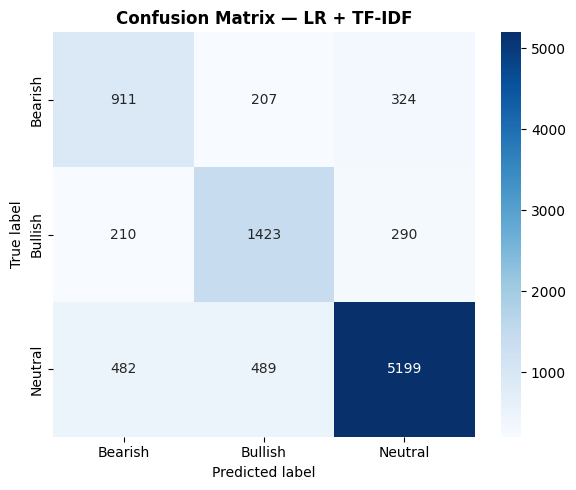

Running CV: XGBoost + TF-IDF...

XGBoost + TF-IDF
              precision    recall  f1-score   support

     Bearish       0.78      0.39      0.52      1442
     Bullish       0.74      0.58      0.65      1923
     Neutral       0.80      0.95      0.87      6170

    accuracy                           0.79      9535
   macro avg       0.78      0.64      0.68      9535
weighted avg       0.79      0.79      0.77      9535



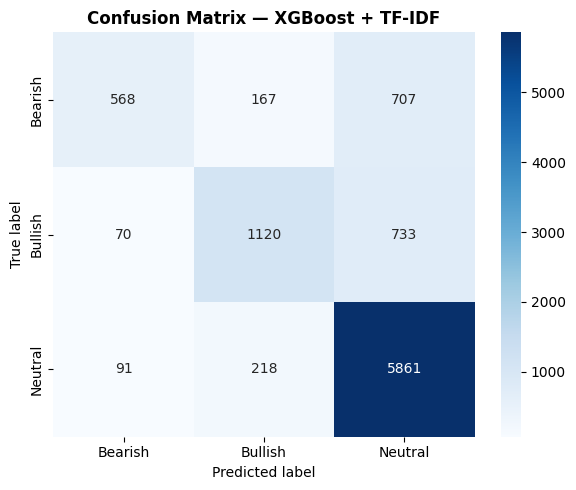

Running CV: MLP + TF-IDF...

MLP + TF-IDF
              precision    recall  f1-score   support

     Bearish       0.64      0.51      0.57      1442
     Bullish       0.71      0.66      0.68      1923
     Neutral       0.85      0.90      0.88      6170

    accuracy                           0.80      9535
   macro avg       0.73      0.69      0.71      9535
weighted avg       0.79      0.80      0.79      9535



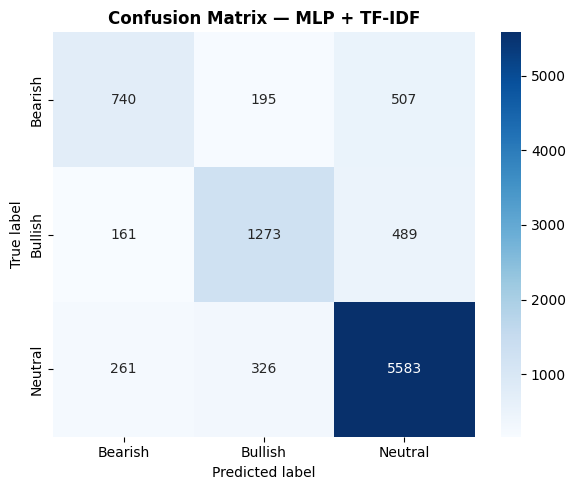

Running CV: RF + BoW...

RF + BoW
              precision    recall  f1-score   support

     Bearish       0.78      0.39      0.52      1442
     Bullish       0.72      0.63      0.67      1923
     Neutral       0.81      0.94      0.87      6170

    accuracy                           0.80      9535
   macro avg       0.77      0.65      0.69      9535
weighted avg       0.79      0.80      0.78      9535



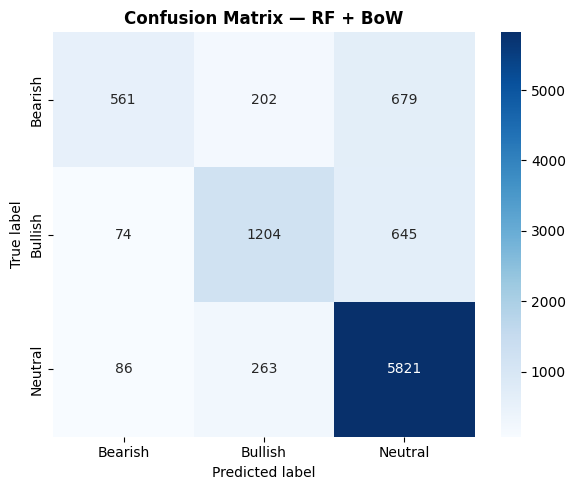

In [215]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from xgboost import XGBClassifier

classical_models = {
    'LR + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")),
        ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'XGBoost + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")),
        ('clf',   XGBClassifier(n_estimators=300, learning_rate=0.1,
                                eval_metric='mlogloss', random_state=42))
    ]),
    'MLP + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")),
        ('clf',   MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300,
                                random_state=42, early_stopping=True))
    ]),
    'RF + BoW': Pipeline([
        ('bow', CountVectorizer(max_features=15000, ngram_range=(1,1), min_df=2, token_pattern=r"[^\s]+")),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                        n_jobs=-1, random_state=42))
    ]),
}

for name, pipeline in classical_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-3'></a>
### 6.3 Traditional ML — Word2Vec Pipeline

Running CV: LR + Word2Vec...

LR + Word2Vec
              precision    recall  f1-score   support

     Bearish       0.31      0.32      0.31      1442
     Bullish       0.42      0.54      0.47      1923
     Neutral       0.81      0.74      0.77      6170

    accuracy                           0.63      9535
   macro avg       0.51      0.53      0.52      9535
weighted avg       0.66      0.63      0.64      9535



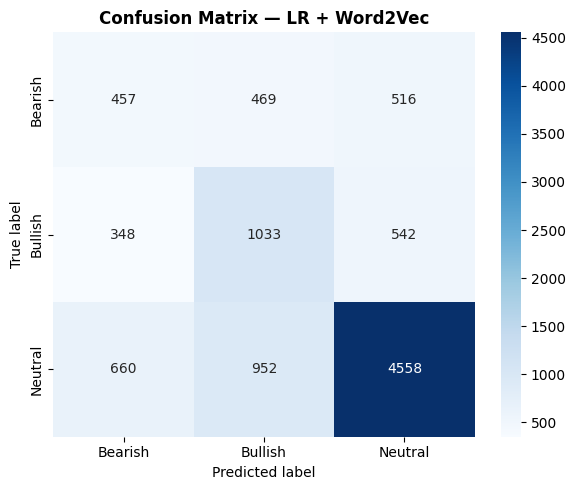

Running CV: MLP + Word2Vec...

MLP + Word2Vec
              precision    recall  f1-score   support

     Bearish       0.42      0.02      0.04      1442
     Bullish       0.51      0.45      0.48      1923
     Neutral       0.74      0.93      0.82      6170

    accuracy                           0.70      9535
   macro avg       0.56      0.47      0.45      9535
weighted avg       0.65      0.70      0.64      9535



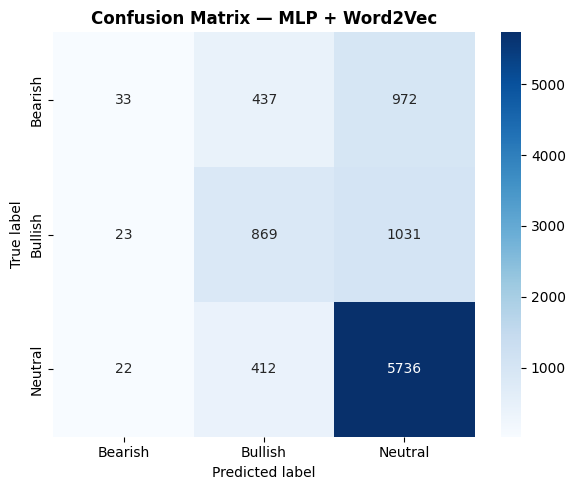

In [216]:
w2v_models = {
    'LR + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300,
                              random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in w2v_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-4'></a>
### 6.4 Transformer Encoder + Classifier Head

In [217]:
# Extract FinBERT embeddings once (cache to avoid re-running)
print('Extracting FinBERT embeddings ...')
X_finbert = get_transformer_embeddings(
    X_transformer.tolist(), model_name='ProsusAI/finbert', batch_size=32
)
print(f'FinBERT embedding shape: {X_finbert.shape}')

# Optional — extra credit (+0.50 pts each)
# X_bert    = get_transformer_embeddings(X_transformer.tolist(), model_name='bert-base-uncased')
# X_roberta = get_transformer_embeddings(X_transformer.tolist(), model_name='roberta-base')

Extracting FinBERT embeddings ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embedding [ProsusAI/finbert]: 100%|██████████| 298/298 [03:37<00:00,  1.37it/s]

FinBERT embedding shape: (9535, 768)


Running CV: LR + FinBERT...

LR + FinBERT
              precision    recall  f1-score   support

     Bearish       0.55      0.72      0.63      1442
     Bullish       0.64      0.75      0.69      1923
     Neutral       0.90      0.78      0.84      6170

    accuracy                           0.77      9535
   macro avg       0.70      0.75      0.72      9535
weighted avg       0.80      0.77      0.78      9535



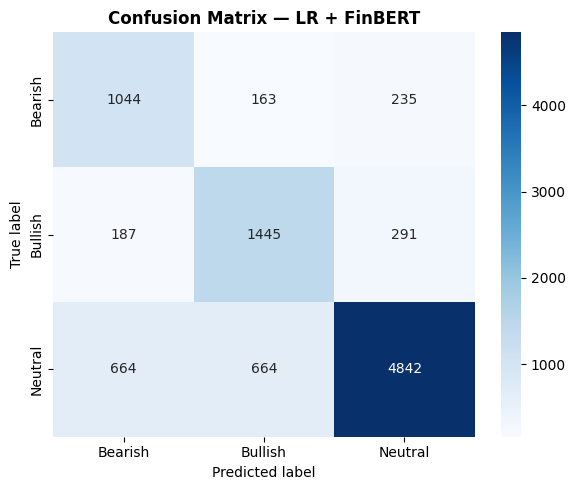

Running CV: MLP + FinBERT...

MLP + FinBERT
              precision    recall  f1-score   support

     Bearish       0.76      0.64      0.70      1442
     Bullish       0.77      0.74      0.75      1923
     Neutral       0.87      0.92      0.89      6170

    accuracy                           0.84      9535
   macro avg       0.80      0.77      0.78      9535
weighted avg       0.84      0.84      0.84      9535



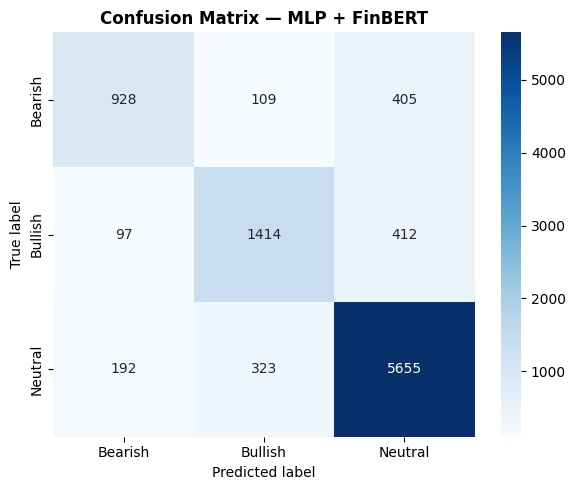

In [218]:
from sklearn.preprocessing import StandardScaler

encoder_models = {
    'LR + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(512,256), max_iter=300,
                              random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in encoder_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_finbert, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-5'></a>
### 6.5 Fine-tuned FinBERT (End-to-end Transformer)

In [219]:
# pip install transformers torch datasets
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset

MODEL_NAME = 'ProsusAI/finbert'
tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer_ft(batch['text'], padding='max_length',
                        truncation=True, max_length=128)

# Use fold 0 for fine-tuning demonstration
train_idx, val_idx = folds[0]
train_ds = Dataset.from_dict({'text': X_transformer.iloc[train_idx].tolist(),
                               'label': y.iloc[train_idx].tolist()})
val_ds   = Dataset.from_dict({'text': X_transformer.iloc[val_idx].tolist(),
                               'label': y.iloc[val_idx].tolist()})
train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

model_ft = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

training_args = TrainingArguments(
    output_dir='./finbert_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=50,
    seed=42,
)
trainer = Trainer(model=model_ft, args=training_args,
                  train_dataset=train_ds, eval_dataset=val_ds)
trainer.train()
print('FinBERT fine-tuning complete.')

Map:   0%|          | 0/7628 [00:00<?, ? examples/s]

Map:   0%|          | 0/1907 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.434553,0.390602
2,0.262132,0.419004
3,0.131466,0.545959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FinBERT fine-tuning complete.



FinBERT Fine-tuned
              precision    recall  f1-score   support

     Bearish       0.85      0.64      0.73       289
     Bullish       0.84      0.76      0.80       384
     Neutral       0.87      0.95      0.91      1234

    accuracy                           0.86      1907
   macro avg       0.85      0.78      0.81      1907
weighted avg       0.86      0.86      0.86      1907



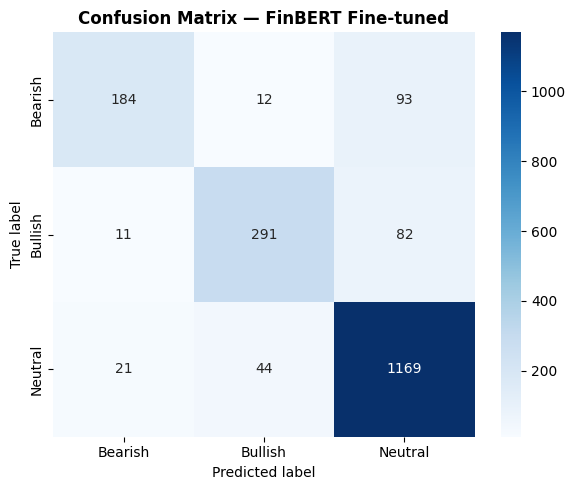

In [220]:
preds_ft   = trainer.predict(val_ds)
y_pred_ft  = preds_ft.predictions.argmax(axis=1)
y_true_ft  = y.iloc[val_idx].tolist()
res = evaluate_model(y_true_ft, y_pred_ft, model_name='FinBERT Fine-tuned')
results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='7'></a>
---
## 7. Evaluation & Analysis

### Metric Interpretation in Context

| Metric | Meaning |
|---|---|
| **Accuracy** | Overall correctness — misleading if classes are imbalanced |
| **F1-Macro** | Average F1 across all 3 classes with equal weight — **primary metric** |
| **F1-Weighted** | F1 weighted by class support — closer to accuracy |
| **Recall per class** | Missing a Bearish signal (low Recall) has real financial cost |
| **Precision per class** | Wrongly flagging Neutral as Bullish (low Precision) misleads investors |

In [221]:
results_df = pd.DataFrame(results_table).sort_values('f1_macro', ascending=False)
results_df[['accuracy','f1_macro','f1_weighted']] = \
    results_df[['accuracy','f1_macro','f1_weighted']].round(4)
print(results_df.to_string(index=False))

             model  accuracy  f1_macro  f1_weighted
FinBERT Fine-tuned    0.8621    0.8106       0.8576
     MLP + FinBERT    0.8387    0.7810       0.8358
       LR + TF-IDF    0.7900    0.7234       0.7940
      LR + FinBERT    0.7689    0.7180       0.7767
      MLP + TF-IDF    0.7966    0.7097       0.7908
          RF + BoW    0.7956    0.6878       0.7794
  XGBoost + TF-IDF    0.7917    0.6823       0.7740
     LR + Word2Vec    0.6343    0.5200       0.6432
    MLP + Word2Vec    0.6962    0.4485       0.6365


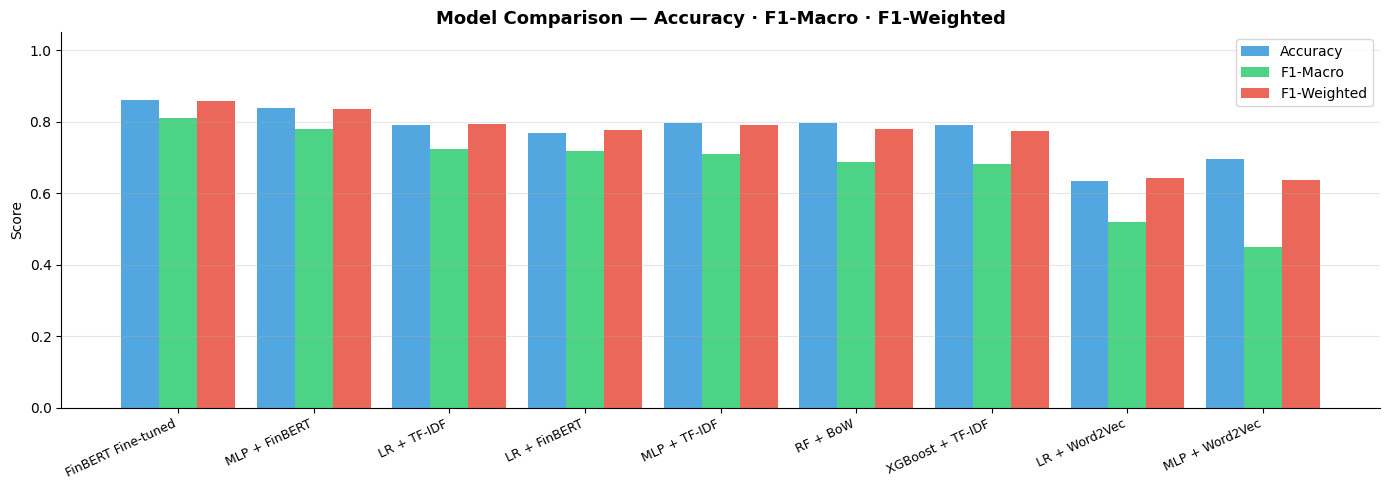

In [222]:
fig, ax = plt.subplots(figsize=(14, 5))
x     = range(len(results_df))
width = 0.28
ax.bar([i-width for i in x], results_df['accuracy'],    width, label='Accuracy',    color='#3498db', alpha=0.85)
ax.bar([i       for i in x], results_df['f1_macro'],    width, label='F1-Macro',    color='#2ecc71', alpha=0.85)
ax.bar([i+width for i in x], results_df['f1_weighted'], width, label='F1-Weighted', color='#e74c3c', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(results_df['model'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy · F1-Macro · F1-Weighted',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='8'></a>
---
## 8. Final Predictions on `test.csv`

Best model retrained on the **full training set**, then applied to `test.csv` → `pred_xx.csv`.

In [223]:
# Retrain best classical model on full training data 
BEST_CLASSICAL = 'LR + TF-IDF'   # replace with whichever scored highest
best_pipeline  = classical_models[BEST_CLASSICAL]
best_pipeline.fit(X_classical, y)
print(f'{BEST_CLASSICAL} retrained on full training set.')

LR + TF-IDF retrained on full training set.


In [224]:
df_test = pd.read_csv('test.csv')
print(f'Test set shape: {df_test.shape}')
print(df_test.head())

X_test_classical   = preprocess_classical(df_test['text'].tolist())
X_test_transformer = preprocess_transformer(df_test['text'].tolist())

Test set shape: (2388, 2)
   id                                               text
0   0  ETF assets to surge tenfold in 10 years to $50...
1   1  Here’s What Hedge Funds Think Evolution Petrol...
2   2  $PVH - Phillips-Van Heusen Q3 2020 Earnings Pr...
3   3  China is in the process of waiving retaliatory...
4   4  Highlight: “When growth is scarce, investors s...


Transformer preprocessing: 100%|██████████| 2388/2388 [00:00<00:00, 89395.03it/s]


In [225]:
# Option A: best classical model
preds_classical = best_pipeline.predict(X_test_classical)

# Option B: fine-tuned FinBERT (recommended if fine-tuning was run)
# test_ds = Dataset.from_dict({'text': X_test_transformer})
# test_ds = test_ds.map(tokenize_fn, batched=True)
# preds_final = trainer.predict(test_ds).predictions.argmax(axis=1)

final_preds = preds_classical   # replace with preds_final if fine-tuning done
print(f'Prediction distribution: {pd.Series(final_preds).value_counts().sort_index().to_dict()}')

Prediction distribution: {0: 402, 1: 532, 2: 1454}


In [226]:
submission = pd.DataFrame({'id': df_test['id'], 'label': final_preds})
submission.to_csv('pred_xx.csv', index=False)
print('Submission saved: pred_xx.csv')
print(submission.head(10))

Submission saved: pred_xx.csv
   id  label
0   0      2
1   1      2
2   2      2
3   3      2
4   4      2
5   5      0
6   6      2
7   7      2
8   8      1
9   9      2


[↑ Back to TOC](#toc)